# Brain Tumor MRI Classification - Model Evaluation

This notebook evaluates the performance of the fine-tuned EfficientNetB0 model on the validation dataset.

The evaluation includes:

- Model performance evaluation
- Prediction generation
- Classification report
- Confusion matrix
- Per-class performance analysis
- Misclassified image analysis

The model is evaluated using a validation dataset that was not used during model training.

## 1. Import Libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_selection import train_test_split
from collections import Counter

import cv2
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

2026-09-03 06:44:25.450790: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/macbookpro2019/MaziyaCode/brain-tumor-classification-ai/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow version: 2.14.0
NumPy version: 1.26.4


## 2. Configuration

In [2]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data" / "raw"
TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"

MODEL_PATH = PROJECT_ROOT / "models" / "efficientnetb0_finetuned.h5"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

NUM_CLASSES = len(CLASS_NAMES)

print("Training directory:", TRAIN_DIR.resolve())
print("Testing directory :", TEST_DIR.resolve())
print("Model path        :", MODEL_PATH.resolve())
print("Image size        :", IMAGE_SIZE)
print("Batch size        :", BATCH_SIZE)
print("Classes           :", CLASS_NAMES)

Training directory: /Users/macbookpro2019/MaziyaCode/brain-tumor-classification-ai/data/raw/Training
Testing directory : /Users/macbookpro2019/MaziyaCode/brain-tumor-classification-ai/data/raw/Testing
Model path        : /Users/macbookpro2019/MaziyaCode/brain-tumor-classification-ai/models/efficientnetb0_finetuned.h5
Image size        : (224, 224)
Batch size        : 32
Classes           : ['glioma', 'meningioma', 'notumor', 'pituitary']


In [3]:
print("\nModel exists:", MODEL_PATH.exists())

if not MODEL_PATH.exists():
    print("WARNING: Fine-tuned model was not found.")


Model exists: True


## 3. Load Validation Dataset

The validation dataset consists of 1,120 images distributed equally across four classes.

Each class contains 280 validation images.

In [4]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="validation",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

print("\nClass names:", validation_dataset.class_names)
print("Number of batches:", tf.data.experimental.cardinality(validation_dataset).numpy())

Found 5600 files belonging to 4 classes.
Using 1120 files for validation.

Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of batches: 35


In [5]:
images, labels = next(iter(validation_dataset))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int32'>


In [6]:
data = []

image_extensions = {".jpg", ".jpeg", ".png"}

for class_name in CLASS_NAMES:
    class_dir = TRAIN_DIR / class_name
    
    for image_path in class_dir.iterdir():
        if image_path.suffix.lower() in image_extensions:
            data.append({
                "filepath": str(image_path),
                "label": class_name
            })

dataset_df = pd.DataFrame(data)

print("Total images:", len(dataset_df))

Total images: 5600


In [7]:
train_df, validation_df = train_test_split(
    dataset_df,
    test_size=0.20,
    stratify=dataset_df["label"],
    random_state=42
)

In [8]:
print("Training:", len(train_df))
print("Validation:", len(validation_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation distribution:")
print(validation_df["label"].value_counts().sort_index())

Training: 4480
Validation: 1120

Training distribution:
label
glioma        1120
meningioma    1120
notumor       1120
pituitary     1120
Name: count, dtype: int64

Validation distribution:
label
glioma        280
meningioma    280
notumor       280
pituitary     280
Name: count, dtype: int64


Validation Dataset

In [9]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)
    
    return image, label

In [10]:
class_to_index = {
    class_name: index
    for index, class_name in enumerate(CLASS_NAMES)
}

print(class_to_index)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


## 4. Load Fine-Tuned Model

In [11]:
validation_paths = validation_df["filepath"].values

validation_labels = validation_df["label"].map(
    class_to_index
).values

Tensor Flow dataset

In [12]:
validation_dataset = tf.data.Dataset.from_tensor_slices(
    (
        validation_paths,
        validation_labels
    )
)

validation_dataset = validation_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_dataset = validation_dataset.batch(
    BATCH_SIZE
)

validation_dataset = validation_dataset.prefetch(
    tf.data.AUTOTUNE
)

Verifikasi

In [13]:
print(
    "Validation batches:",
    tf.data.experimental.cardinality(validation_dataset).numpy()
)

images, labels = next(iter(validation_dataset))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Unique labels:", np.unique(labels.numpy()))

Validation batches: 35
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Unique labels: [0 1 2 3]


In [14]:
all_labels = []

for _, labels in validation_dataset:
    all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)

print("\nValidation distribution:")
print(np.bincount(all_labels, minlength=NUM_CLASSES))


Validation distribution:
[280 280 280 280]


In [15]:
fine_tuned_model = tf.keras.models.load_model(
    MODEL_PATH
)

print("Fine-tuned model loaded successfully.\n")

fine_tuned_model.summary()

Fine-tuned model loaded successfully.

Model: "brain_tumor_efficientnetb0"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequent  (None, 224, 224, 3)       0         
 ial)                                                            
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling (Gl  (None, 1280)              0         
 obalAveragePooling2D)                                           
                                                                 
 dropout (Dropout)           (None, 1280)              0         
 

### Model Verification

In [16]:
print("Model input shape :", fine_tuned_model.input_shape)
print("Model output shape:", fine_tuned_model.output_shape)
print("Number of classes :", NUM_CLASSES)
print("Class names       :", CLASS_NAMES)

Model input shape : (None, 224, 224, 3)
Model output shape: (None, 4)
Number of classes : 4
Class names       : ['glioma', 'meningioma', 'notumor', 'pituitary']


In [17]:
sample_images, sample_labels = next(iter(validation_dataset))

sample_predictions = fine_tuned_model.predict(
    sample_images,
    verbose=0
)

print("Images shape      :", sample_images.shape)
print("Labels shape      :", sample_labels.shape)
print("Predictions shape :", sample_predictions.shape)

print("\nFirst prediction:")
print(sample_predictions[0])

print("\nPrediction sum:")
print(np.sum(sample_predictions[0]))

Images shape      : (32, 224, 224, 3)
Labels shape      : (32,)
Predictions shape : (32, 4)

First prediction:
[3.15719455e-01 1.00982286e-01 5.38187509e-04 5.82760036e-01]

Prediction sum:
1.0


## 5. Model Evaluation

The fine-tuned EfficientNetB0 model is evaluated on the complete validation dataset.

The evaluation metrics include:

- Validation Loss
- Validation Accuracy

In [18]:
validation_loss, validation_accuracy = fine_tuned_model.evaluate(
    validation_dataset,
    verbose=1
)

print("\nValidation Loss     :", validation_loss)
print("Validation Accuracy :", validation_accuracy)

35/35 [==============================] - 44s 1s/step - loss: 0.1607 - accuracy: 0.9393

Validation Loss     : 0.16065655648708344
Validation Accuracy : 0.9392856955528259


## 6. Generate Predictions

Predictions are generated for the complete validation dataset.

Both the true labels and predicted labels are collected for further evaluation.

In [19]:
y_true = []
y_pred = []
y_prob = []

for images, labels in validation_dataset:
    
    predictions = fine_tuned_model.predict(
        images,
        verbose=0
    )
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))
    y_prob.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("True labels shape      :", y_true.shape)
print("Predicted labels shape :", y_pred.shape)
print("Prediction probabilities shape:", y_prob.shape)

True labels shape      : (1120,)
Predicted labels shape : (1120,)
Prediction probabilities shape: (1120, 4)


Prediction Verification

In [20]:
print("True label distribution:")
print(np.bincount(y_true, minlength=NUM_CLASSES))

print("\nPredicted label distribution:")
print(np.bincount(y_pred, minlength=NUM_CLASSES))

True label distribution:
[280 280 280 280]

Predicted label distribution:
[285 232 277 326]


In [21]:
# Cek jumlah prediksi yang benar dan salah

correct_predictions = np.sum(y_true == y_pred)
incorrect_predictions = np.sum(y_true != y_pred)

print("Correct predictions  :", correct_predictions)
print("Incorrect predictions:", incorrect_predictions)

print(
    "Accuracy:",
    correct_predictions / len(y_true)
)

Correct predictions  : 1052
Incorrect predictions: 68
Accuracy: 0.9392857142857143


## 7. Classification Report

In [22]:
report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4
)

print("Classification Report")
print(report)

Classification Report
              precision    recall  f1-score   support

      glioma     0.9474    0.9643    0.9558       280
  meningioma     0.9741    0.8071    0.8828       280
     notumor     0.9964    0.9857    0.9910       280
   pituitary     0.8589    1.0000    0.9241       280

    accuracy                         0.9393      1120
   macro avg     0.9442    0.9393    0.9384      1120
weighted avg     0.9442    0.9393    0.9384      1120



## 8. Confussion Matrix

In [23]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[270   4   0   6]
 [ 15 226   1  38]
 [  0   2 276   2]
 [  0   0   0 280]]


## 9. Prediction Visualization

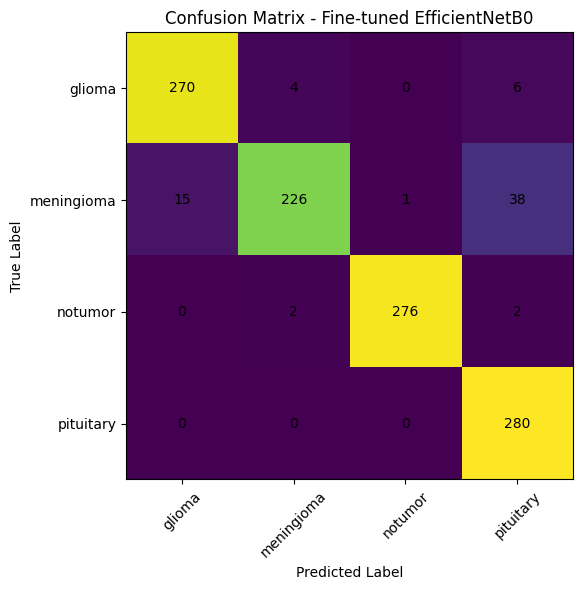

In [24]:
plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.xticks(
    range(len(CLASS_NAMES)),
    CLASS_NAMES,
    rotation=45
)

plt.yticks(
    range(len(CLASS_NAMES)),
    CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fine-tuned EfficientNetB0")

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

## 10. Load Testing Dataset

In [25]:
testing_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Testing dataset loaded successfully.")
print("Testing batches:", len(testing_dataset))

Found 1600 files belonging to 4 classes.
Testing dataset loaded successfully.
Testing batches: 50


In [26]:
# Ambil satu batch untuk verifikasi
test_images, test_labels = next(iter(testing_dataset))

print("Images shape :", test_images.shape)
print("Labels shape :", test_labels.shape)
print("Image dtype  :", test_images.dtype)
print("Label dtype  :", test_labels.dtype)

Images shape : (32, 224, 224, 3)
Labels shape : (32,)
Image dtype  : <dtype: 'float32'>
Label dtype  : <dtype: 'int32'>


In [27]:
# Testing Class Distribution

test_labels_all = []

for _, labels in testing_dataset:
    test_labels_all.extend(labels.numpy())

test_labels_all = np.array(test_labels_all)

print("Testing label distribution:")
print(np.bincount(test_labels_all))

Testing label distribution:
[400 400 400 400]


In [28]:
print("Class names:", CLASS_NAMES)
print("Number of classes:", len(CLASS_NAMES))

Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4


In [29]:
print("Total testing images:", len(test_labels_all))

Total testing images: 1600


In [30]:
# ============================================
# 8. Evaluate Fine-Tuned Model on Testing Set
# ============================================

test_loss, test_accuracy = fine_tuned_model.evaluate(
    testing_dataset,
    verbose=1
)

print("\nTesting Loss     :", test_loss)
print("Testing Accuracy :", test_accuracy)

50/50 [==============================] - 61s 1s/step - loss: 0.4736 - accuracy: 0.8850

Testing Loss     : 0.47361624240875244
Testing Accuracy : 0.8849999904632568


In [31]:
# ============================================
# 9. Generate Testing Predictions
# ============================================

y_test_true = []
y_test_pred = []
y_test_prob = []

for images, labels in testing_dataset:

    predictions = fine_tuned_model.predict(
        images,
        verbose=0
    )

    y_test_true.extend(labels.numpy())
    y_test_pred.extend(np.argmax(predictions, axis=1))
    y_test_prob.extend(predictions)

y_test_true = np.array(y_test_true)
y_test_pred = np.array(y_test_pred)
y_test_prob = np.array(y_test_prob)

print("True labels shape      :", y_test_true.shape)
print("Predicted labels shape :", y_test_pred.shape)
print("Prediction probabilities shape:", y_test_prob.shape)

True labels shape      : (1600,)
Predicted labels shape : (1600,)
Prediction probabilities shape: (1600, 4)


In [32]:
print("\nTrue label distribution:")
print(np.bincount(y_test_true, minlength=len(CLASS_NAMES)))

print("\nPredicted label distribution:")
print(np.bincount(y_test_pred, minlength=len(CLASS_NAMES)))


True label distribution:
[400 400 400 400]

Predicted label distribution:
[314 362 434 490]


In [33]:
# ============================================
# 10. Testing Classification Report
# ============================================

from sklearn.metrics import classification_report

test_report = classification_report(
    y_test_true,
    y_test_pred,
    target_names=CLASS_NAMES,
    digits=4
)

print("Testing Classification Report")
print(test_report)

Testing Classification Report
              precision    recall  f1-score   support

      glioma     0.9522    0.7475    0.8375       400
  meningioma     0.8785    0.7950    0.8346       400
     notumor     0.9194    0.9975    0.9568       400
   pituitary     0.8163    1.0000    0.8989       400

    accuracy                         0.8850      1600
   macro avg     0.8916    0.8850    0.8820      1600
weighted avg     0.8916    0.8850    0.8820      1600



In [34]:
# ============================================
# 11. Testing Confusion Matrix
# ============================================

from sklearn.metrics import confusion_matrix

cm_test = confusion_matrix(
    y_test_true,
    y_test_pred
)

print("Testing Confusion Matrix:")
print(cm_test)

Testing Confusion Matrix:
[[299  44  28  29]
 [ 15 318   7  60]
 [  0   0 399   1]
 [  0   0   0 400]]


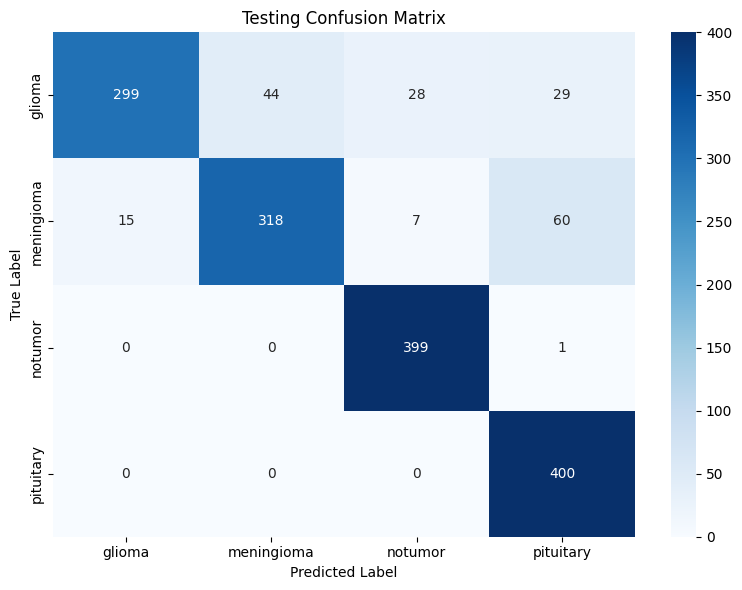

In [35]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Testing Confusion Matrix")

plt.tight_layout()
plt.show()

## 11. Error Analysis

In [36]:
misclassified_indices = np.where(
    y_test_true != y_test_pred
)[0]

print("Total testing images      :", len(y_test_true))
print("Correct predictions       :", np.sum(y_test_true == y_test_pred))
print("Incorrect predictions     :", len(misclassified_indices))
print("Misclassification rate    :", len(misclassified_indices) / len(y_test_true))

Total testing images      : 1600
Correct predictions       : 1416
Incorrect predictions     : 184
Misclassification rate    : 0.115


Misclasification Analysis

In [37]:
misclassification_pairs = Counter(
    zip(
        y_test_true[misclassified_indices],
        y_test_pred[misclassified_indices]
    )
)

rows = []

for (true_label, predicted_label), count in misclassification_pairs.items():
    rows.append({
        "Actual": CLASS_NAMES[true_label],
        "Predicted": CLASS_NAMES[predicted_label],
        "Count": count
    })

misclassification_df = pd.DataFrame(rows)

misclassification_df = misclassification_df.sort_values(
    by="Count",
    ascending=False
).reset_index(drop=True)

print("Misclassification Pairs:")
display(misclassification_df)

Misclassification Pairs:


,Actual,Predicted,Count
0,meningioma,pituitary,60
1,glioma,meningioma,44
2,glioma,pituitary,29
3,glioma,notumor,28
4,meningioma,glioma,15
5,meningioma,notumor,7
6,notumor,pituitary,1


In [38]:
# ============================================
# 14. Error Distribution by Actual Class
# ============================================

error_by_class = []

for class_index, class_name in enumerate(CLASS_NAMES):

    total_class = np.sum(y_test_true == class_index)
    incorrect_class = np.sum(
        (y_test_true == class_index) &
        (y_test_pred != class_index)
    )

    error_by_class.append({
        "Class": class_name,
        "Total": total_class,
        "Incorrect": incorrect_class,
        "Error Rate": incorrect_class / total_class
    })

error_by_class_df = pd.DataFrame(error_by_class)

print("Error Distribution by Actual Class:")
display(error_by_class_df)

Error Distribution by Actual Class:


,Class,Total,Incorrect,Error Rate
0,glioma,400,101,0.2525
1,meningioma,400,82,0.2050
2,notumor,400,1,0.0025
3,pituitary,400,0,0.0000


In [39]:
# ============================================
# 15. Collect Testing Images
# ============================================

test_images_all = []

for images, _ in testing_dataset:
    test_images_all.append(images.numpy())

test_images_all = np.concatenate(test_images_all, axis=0)

print("Testing images shape:", test_images_all.shape)

Testing images shape: (1600, 224, 224, 3)


In [40]:
# ============================================
# 16. Visualize Misclassified Images
# ============================================

def show_misclassified_images(
    actual_class,
    predicted_class,
    max_images=8
):
    
    actual_index = CLASS_NAMES.index(actual_class)
    predicted_index = CLASS_NAMES.index(predicted_class)

    indices = np.where(
        (y_test_true == actual_index) &
        (y_test_pred == predicted_index)
    )[0]

    indices = indices[:max_images]

    print(
        f"Actual: {actual_class} → "
        f"Predicted: {predicted_class}"
    )
    print("Number of samples:", len(indices))

    plt.figure(figsize=(16, 8))

    for i, index in enumerate(indices):

        plt.subplot(2, 4, i + 1)

        plt.imshow(
            test_images_all[index].astype("uint8")
        )

        confidence = y_test_prob[index][predicted_index] * 100

        plt.title(
            f"Actual: {actual_class}\n"
            f"Pred: {predicted_class}\n"
            f"Conf: {confidence:.2f}%"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

Actual: meningioma → Predicted: pituitary
Number of samples: 8


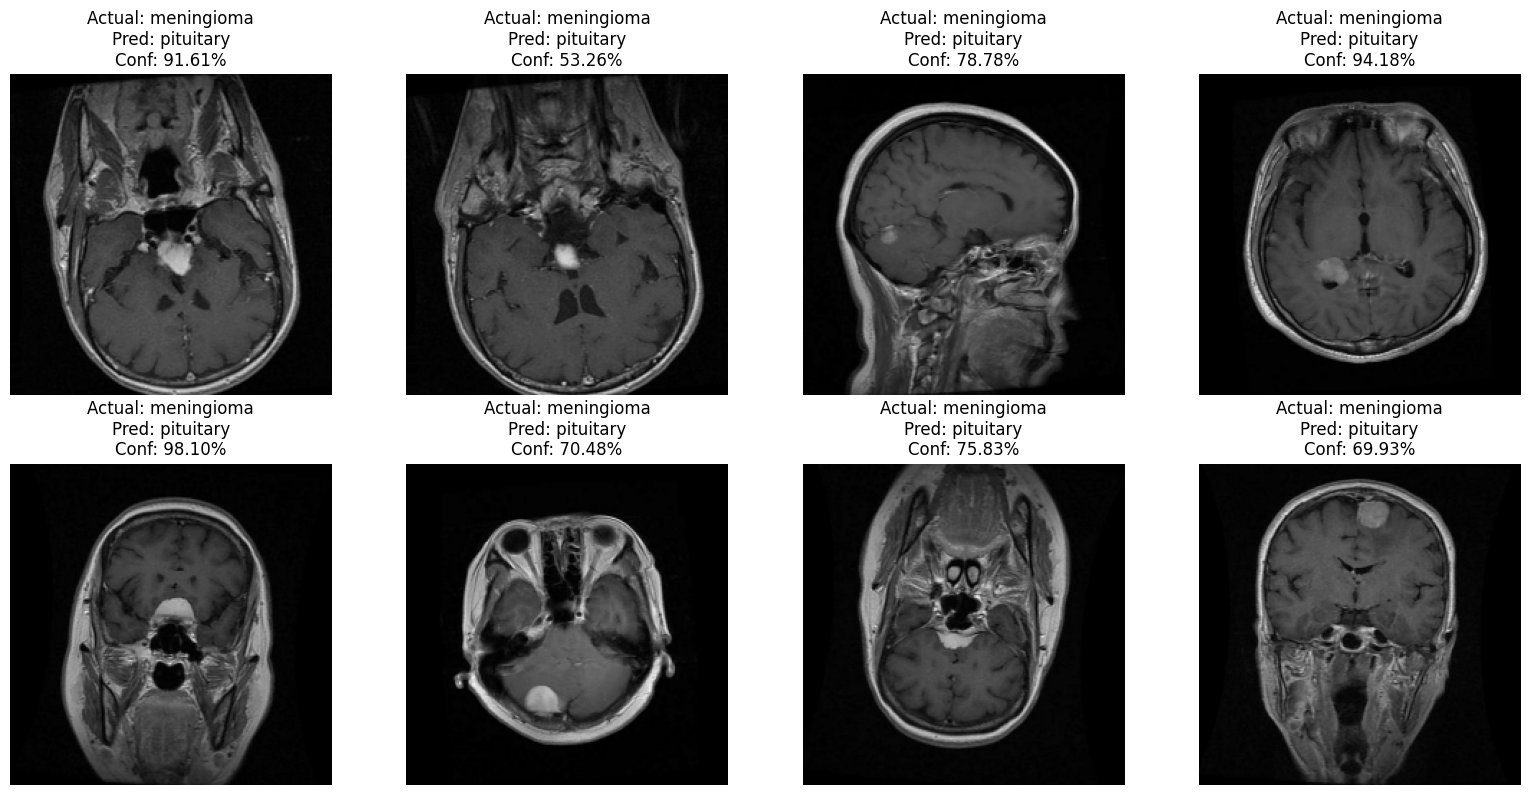

In [41]:
show_misclassified_images(
    "meningioma",
    "pituitary"
)

Actual: glioma → Predicted: meningioma
Number of samples: 8


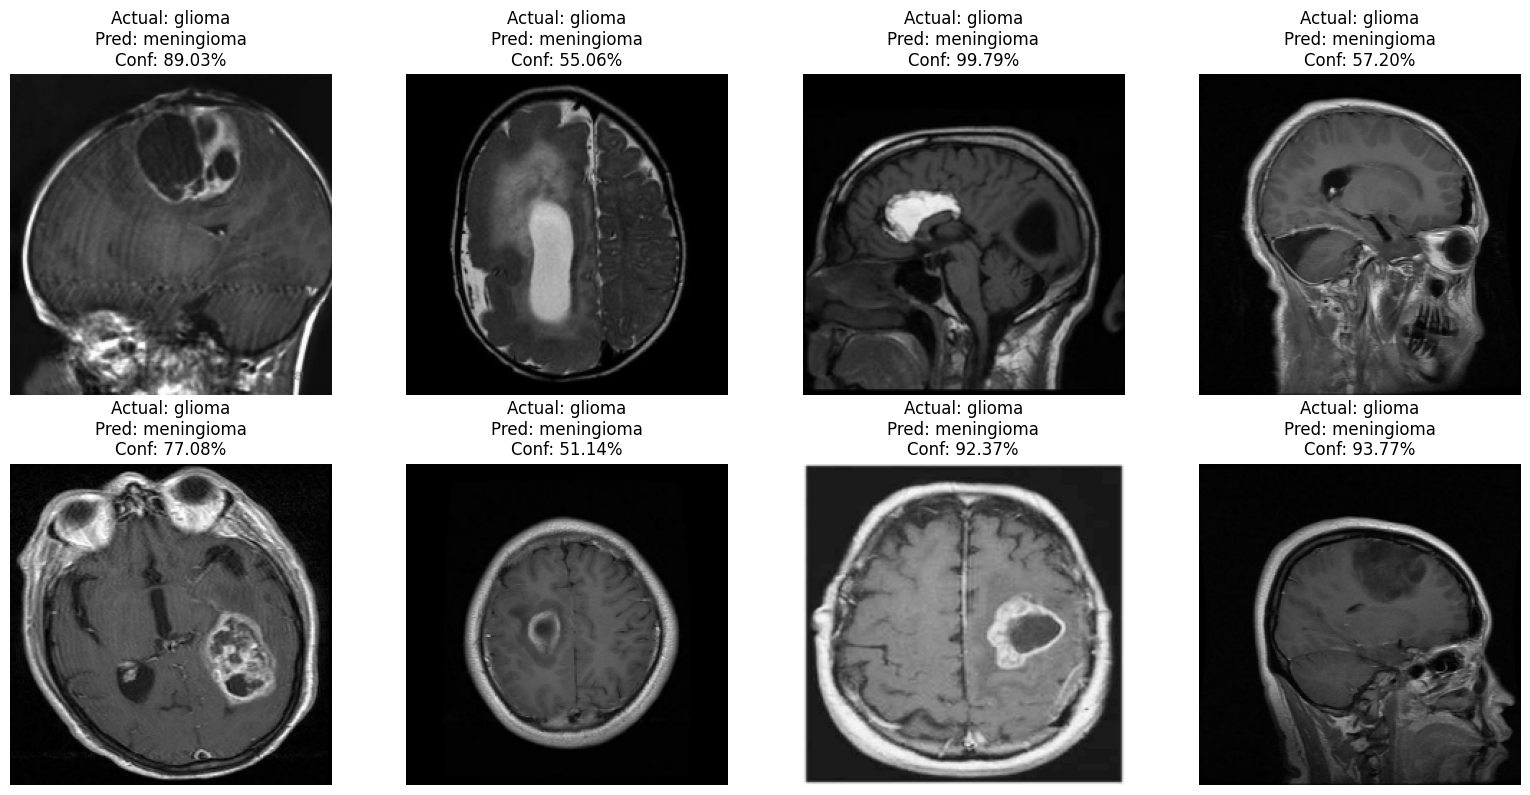

In [42]:
show_misclassified_images(
    "glioma",
    "meningioma"
)

Actual: glioma → Predicted: pituitary
Number of samples: 8


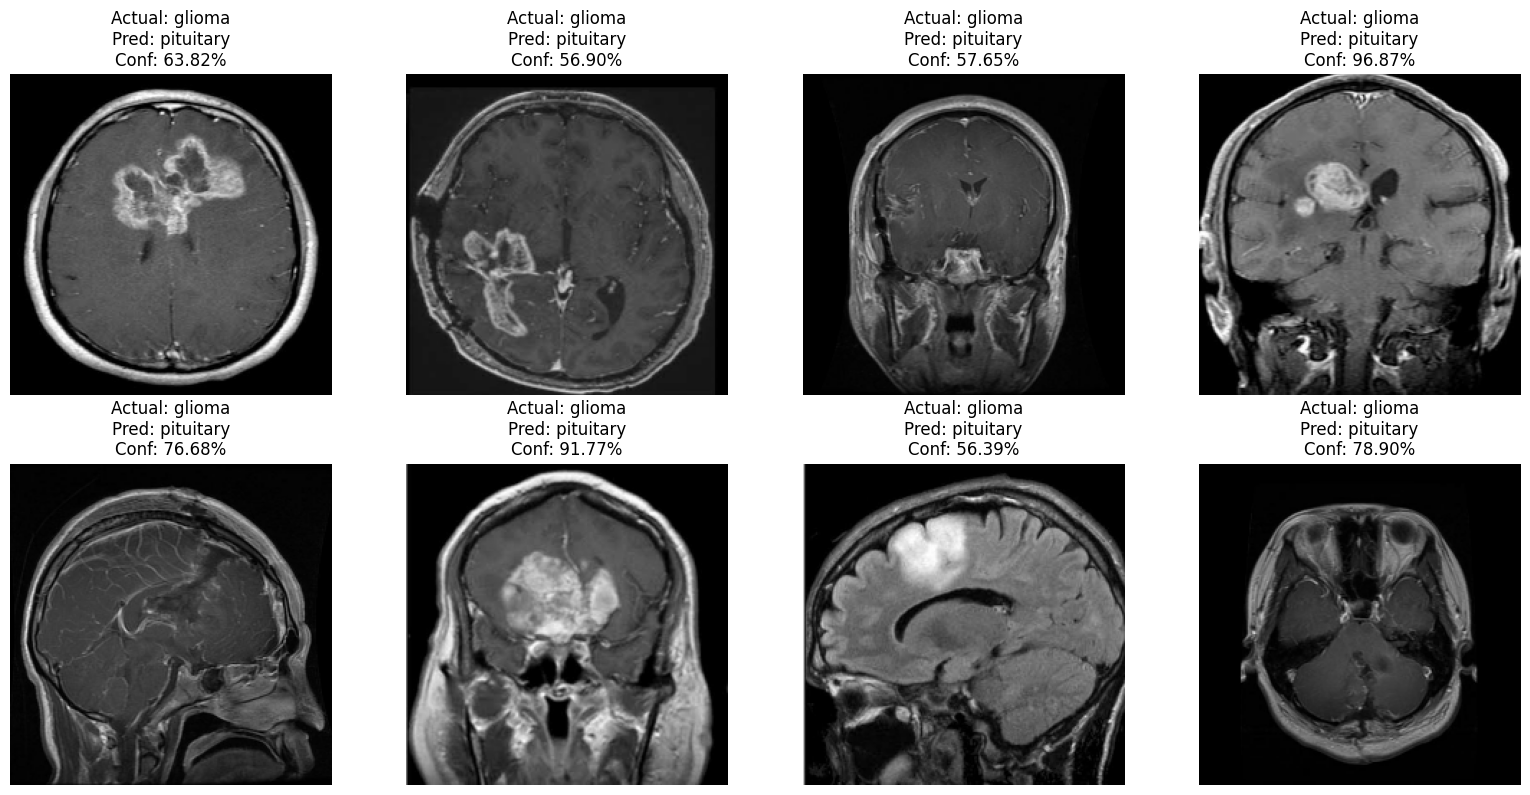

In [43]:
show_misclassified_images(
    "glioma",
    "pituitary"
)

## 12. Confidence Analysis

In [44]:
print("True labels shape :", y_true.shape)
print("Predicted labels shape :", y_pred.shape)
print("Prediction probabilities shape :", y_prob.shape)

print("\nNumber of samples:", len(y_true))
print("Number of predictions:", len(y_pred))
print("Number of probability vectors:", len(y_prob))

True labels shape : (1120,)
Predicted labels shape : (1120,)
Prediction probabilities shape : (1120, 4)

Number of samples: 1120
Number of predictions: 1120
Number of probability vectors: 1120


In [45]:
confidence = np.max(y_prob, axis=1)

print("Confidence shape:", confidence.shape)

print("\nMinimum confidence :", confidence.min())
print("Maximum confidence :", confidence.max())
print("Mean confidence    :", confidence.mean())
print("Median confidence  :", np.median(confidence))

Confidence shape: (1120,)

Minimum confidence : 0.3916523
Maximum confidence : 0.99999994
Mean confidence    : 0.9423501
Median confidence  : 0.99821573


In [46]:
confidence_df = pd.DataFrame({
    "true_label": y_true,
    "predicted_label": y_pred,
    "confidence": confidence
})

confidence_df["true_class"] = confidence_df["true_label"].map(
    {i: name for i, name in enumerate(CLASS_NAMES)}
)

confidence_df["predicted_class"] = confidence_df["predicted_label"].map(
    {i: name for i, name in enumerate(CLASS_NAMES)}
)

confidence_df["correct"] = (
    confidence_df["true_label"] == confidence_df["predicted_label"]
)

confidence_df.head()

,true_label,predicted_label,confidence,true_class,predicted_class,correct
0,0,3,0.582760,glioma,pituitary,False
1,1,0,0.757916,meningioma,glioma,False
2,3,3,0.997883,pituitary,pituitary,True
3,0,0,0.994053,glioma,glioma,True
4,0,0,0.999773,glioma,glioma,True


In [47]:
correct_confidence = confidence_df[
    confidence_df["correct"]
]["confidence"]

incorrect_confidence = confidence_df[
    ~confidence_df["correct"]
]["confidence"]

print("Correct predictions:", len(correct_confidence))
print("Incorrect predictions:", len(incorrect_confidence))

print("\nCorrect prediction confidence")
print("Mean   :", correct_confidence.mean())
print("Median :", correct_confidence.median())

print("\nIncorrect prediction confidence")
print("Mean   :", incorrect_confidence.mean())
print("Median :", incorrect_confidence.median())

Correct predictions: 1052
Incorrect predictions: 68

Correct prediction confidence
Mean   : 0.9560593
Median : 0.99875176

Incorrect prediction confidence
Mean   : 0.730262
Median : 0.7370602


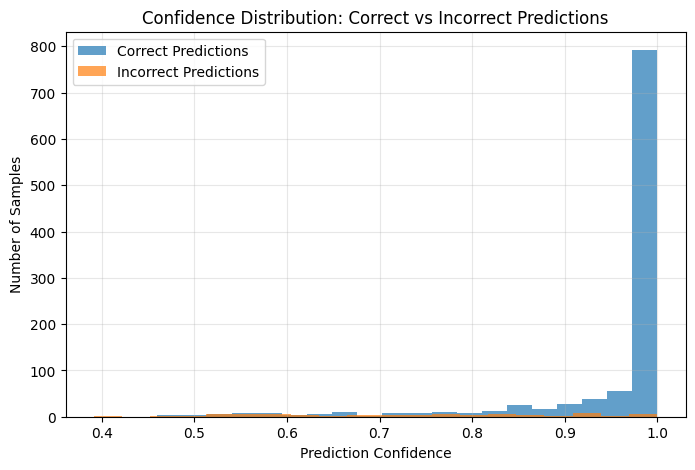

In [48]:
plt.figure(figsize=(8, 5))

plt.hist(
    correct_confidence,
    bins=20,
    alpha=0.7,
    label="Correct Predictions"
)

plt.hist(
    incorrect_confidence,
    bins=20,
    alpha=0.7,
    label="Incorrect Predictions"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Samples")
plt.title("Confidence Distribution: Correct vs Incorrect Predictions")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [49]:
high_conf_errors = confidence_df[
    (~confidence_df["correct"]) &
    (confidence_df["confidence"] >= 0.90)
].copy()

high_conf_errors = high_conf_errors.sort_values(
    by="confidence",
    ascending=False
)

print("High-confidence errors (>= 90%):")
print("Number of samples:", len(high_conf_errors))

high_conf_errors.head(20)

High-confidence errors (>= 90%):
Number of samples: 15


,true_label,predicted_label,confidence,true_class,predicted_class,correct
707,1,2,0.999563,meningioma,notumor,False
818,1,0,0.989589,meningioma,glioma,False
1092,1,3,0.988487,meningioma,pituitary,False
623,1,3,0.982527,meningioma,pituitary,False
351,1,3,0.977715,meningioma,pituitary,False
515,1,3,0.959418,meningioma,pituitary,False
1055,1,0,0.955666,meningioma,glioma,False
135,2,3,0.937278,notumor,pituitary,False
191,1,0,0.929877,meningioma,glioma,False
491,1,3,0.929833,meningioma,pituitary,False


In [50]:
class_confidence = (
    confidence_df
    .groupby("true_class")["confidence"]
    .agg(["count", "mean", "median", "min", "max"])
)

class_confidence

,count,mean,median,min,max
true_class,,,,,
glioma,280,0.944448,0.997358,0.391652,0.999999
meningioma,280,0.851319,0.909111,0.459460,0.999984
notumor,280,0.976048,0.999367,0.515043,1.000000
pituitary,280,0.997585,0.999864,0.891314,1.000000


In [51]:
error_by_class = (
    confidence_df[~confidence_df["correct"]]
    .groupby("true_class")["confidence"]
    .agg(["count", "mean", "median", "min", "max"])
)

error_by_class

,count,mean,median,min,max
true_class,,,,,
glioma,10,0.651135,0.605419,0.391652,0.904047
meningioma,54,0.749780,0.757940,0.463746,0.999563
notumor,4,0.664586,0.602148,0.516771,0.937278


In [52]:
meningioma_pituitary = confidence_df[
    (confidence_df["true_class"] == "meningioma") &
    (confidence_df["predicted_class"] == "pituitary")
].copy()

meningioma_pituitary = meningioma_pituitary.sort_values(
    by="confidence",
    ascending=False
)

print("Meningioma → Pituitary")
print("Number of samples:", len(meningioma_pituitary))

print("\nConfidence statistics:")
print(meningioma_pituitary["confidence"].describe())

meningioma_pituitary.head(10)

Meningioma → Pituitary
Number of samples: 38

Confidence statistics:
count    38.000000
mean      0.765725
std       0.141335
min       0.463746
25%       0.672537
50%       0.769202
75%       0.888182
max       0.988487
Name: confidence, dtype: float64


,true_label,predicted_label,confidence,true_class,predicted_class,correct
1092,1,3,0.988487,meningioma,pituitary,False
623,1,3,0.982527,meningioma,pituitary,False
351,1,3,0.977715,meningioma,pituitary,False
515,1,3,0.959418,meningioma,pituitary,False
491,1,3,0.929833,meningioma,pituitary,False
757,1,3,0.921544,meningioma,pituitary,False
482,1,3,0.915612,meningioma,pituitary,False
753,1,3,0.915213,meningioma,pituitary,False
620,1,3,0.909202,meningioma,pituitary,False
206,1,3,0.892012,meningioma,pituitary,False


In [53]:
thresholds = [0.50, 0.70, 0.80, 0.90, 0.95]

for threshold in thresholds:
    
    mask = confidence >= threshold
    
    total = np.sum(mask)
    correct = np.sum(
        confidence_df.loc[mask, "correct"]
    )
    
    accuracy = correct / total if total > 0 else 0
    
    print(
        f"Confidence >= {threshold:.0%} | "
        f"Samples: {total:4d} | "
        f"Accuracy: {accuracy:.4f}"
    )

Confidence >= 50% | Samples: 1114 | Accuracy: 0.9417
Confidence >= 70% | Samples: 1041 | Accuracy: 0.9635
Confidence >= 80% | Samples:  994 | Accuracy: 0.9738
Confidence >= 90% | Samples:  920 | Accuracy: 0.9837
Confidence >= 95% | Samples:  845 | Accuracy: 0.9917


## 13. Testing Confidence Analysis

In [54]:
y_true_test = []
y_pred_test = []
y_prob_test = []

for images, labels in testing_dataset:

    predictions = fine_tuned_model.predict(
        images,
        verbose=0
    )

    y_true_test.extend(labels.numpy())
    y_pred_test.extend(np.argmax(predictions, axis=1))
    y_prob_test.extend(predictions)

y_true_test = np.array(y_true_test)
y_pred_test = np.array(y_pred_test)
y_prob_test = np.array(y_prob_test)

print("True labels shape      :", y_true_test.shape)
print("Predicted labels shape :", y_pred_test.shape)
print("Prediction probabilities shape:", y_prob_test.shape)

True labels shape      : (1600,)
Predicted labels shape : (1600,)
Prediction probabilities shape: (1600, 4)


In [55]:
print("True label distribution:")
print(np.bincount(y_true_test, minlength=len(CLASS_NAMES)))

print("\nPredicted label distribution:")
print(np.bincount(y_pred_test, minlength=len(CLASS_NAMES)))

print("\nClass names:")
print(CLASS_NAMES)

True label distribution:
[400 400 400 400]

Predicted label distribution:
[314 362 434 490]

Class names:
['glioma', 'meningioma', 'notumor', 'pituitary']


In [56]:
test_confidence = np.max(y_prob_test, axis=1)

test_correct = (y_true_test == y_pred_test)

print("Confidence shape:", test_confidence.shape)

print("Minimum confidence :", test_confidence.min())
print("Maximum confidence :", test_confidence.max())
print("Mean confidence    :", test_confidence.mean())
print("Median confidence  :", np.median(test_confidence))

Confidence shape: (1600,)
Minimum confidence : 0.38768354
Maximum confidence : 0.99999994
Mean confidence    : 0.93359315
Median confidence  : 0.99706703


In [57]:
# Make DataFrame for confidence testing

test_confidence_df = pd.DataFrame({
    "true_label": y_true_test,
    "predicted_label": y_pred_test,
    "confidence": test_confidence
})

test_confidence_df["true_class"] = test_confidence_df["true_label"].map(
    dict(enumerate(CLASS_NAMES))
)

test_confidence_df["predicted_class"] = test_confidence_df["predicted_label"].map(
    dict(enumerate(CLASS_NAMES))
)

test_confidence_df["correct"] = test_correct

test_confidence_df.head()

,true_label,predicted_label,confidence,true_class,predicted_class,correct
0,0,3,0.638175,glioma,pituitary,False
1,0,0,0.999153,glioma,glioma,True
2,0,0,0.991645,glioma,glioma,True
3,0,0,0.842908,glioma,glioma,True
4,0,3,0.569020,glioma,pituitary,False


In [58]:
# Confidence distribution for correct and incorrect predictions
correct_confidence = test_confidence_df[
    test_confidence_df["correct"] == True
]["confidence"]

incorrect_confidence = test_confidence_df[
    test_confidence_df["correct"] == False
]["confidence"]

print("Correct predictions:", len(correct_confidence))
print("Incorrect predictions:", len(incorrect_confidence))

print("\nCorrect prediction confidence")
print("Mean   :", correct_confidence.mean())
print("Median :", correct_confidence.median())
print("Min    :", correct_confidence.min())
print("Max    :", correct_confidence.max())

print("\nIncorrect prediction confidence")
print("Mean   :", incorrect_confidence.mean())
print("Median :", incorrect_confidence.median())
print("Min    :", incorrect_confidence.min())
print("Max    :", incorrect_confidence.max())

Correct predictions: 1416
Incorrect predictions: 184

Correct prediction confidence
Mean   : 0.95550925
Median : 0.9984232
Min    : 0.43433878
Max    : 0.99999994

Incorrect prediction confidence
Mean   : 0.7649341
Median : 0.7739148
Min    : 0.38768354
Max    : 0.9995629


In [59]:
HIGH_CONF_THRESHOLD = 0.90

high_conf_errors = test_confidence_df[
    (test_confidence_df["correct"] == False) &
    (test_confidence_df["confidence"] >= HIGH_CONF_THRESHOLD)
].sort_values(
    by="confidence",
    ascending=False
)

print(
    "High-confidence errors (>= 90%):",
    len(high_conf_errors)
)

high_conf_errors


High-confidence errors (>= 90%): 58


,true_label,predicted_label,confidence,true_class,predicted_class,correct
725,1,2,0.999563,meningioma,notumor,False
521,1,3,0.998917,meningioma,pituitary,False
11,0,1,0.997881,glioma,meningioma,False
342,0,1,0.996698,glioma,meningioma,False
792,1,3,0.995166,meningioma,pituitary,False
538,1,3,0.994982,meningioma,pituitary,False
372,0,2,0.994223,glioma,notumor,False
117,0,2,0.993594,glioma,notumor,False
177,0,2,0.993594,glioma,notumor,False
544,1,0,0.992904,meningioma,glioma,False


In [60]:
confidence_by_class = test_confidence_df.groupby(
    "true_class"
)["confidence"].agg(
    ["count", "mean", "median", "min", "max"]
)

confidence_by_class

,count,mean,median,min,max
true_class,,,,,
glioma,400,0.905378,0.985409,0.434339,0.999998
meningioma,400,0.847891,0.919785,0.387684,0.999968
notumor,400,0.985605,0.999439,0.408027,1.000000
pituitary,400,0.995499,0.999825,0.576118,0.999999


In [61]:
incorrect_by_class = test_confidence_df[
    test_confidence_df["correct"] == False
].groupby(
    "true_class"
)["confidence"].agg(
    ["count", "mean", "median", "min", "max"]
)

incorrect_by_class

,count,mean,median,min,max
true_class,,,,,
glioma,101,0.790524,0.853633,0.471081,0.997881
meningioma,82,0.737767,0.702036,0.387684,0.999563
notumor,1,0.408027,0.408027,0.408027,0.408027


In [62]:
meningioma_pituitary = test_confidence_df[
    (test_confidence_df["true_class"] == "meningioma") &
    (test_confidence_df["predicted_class"] == "pituitary")
].sort_values(
    by="confidence",
    ascending=False
)

print(
    "Meningioma → Pituitary",
    "Number of samples:",
    len(meningioma_pituitary)
)

meningioma_pituitary["confidence"].describe()

Meningioma → Pituitary Number of samples: 60


count    60.000000
mean      0.730385
std       0.174948
min       0.387684
25%       0.601765
50%       0.702036
75%       0.887005
max       0.998917
Name: confidence, dtype: float64

In [63]:
# Confidence Threshold Analysis
thresholds = [0.50, 0.70, 0.80, 0.90, 0.95]

for threshold in thresholds:

    mask = test_confidence_df["confidence"] >= threshold

    samples = mask.sum()

    if samples > 0:
        accuracy = test_confidence_df.loc[
            mask,
            "correct"
        ].mean()

        print(
            f"Confidence >= {threshold:.0%} | "
            f"Samples: {samples:4d} | "
            f"Accuracy: {accuracy:.4f}"
        )

Confidence >= 50% | Samples: 1582 | Accuracy: 0.8906
Confidence >= 70% | Samples: 1452 | Accuracy: 0.9263
Confidence >= 80% | Samples: 1378 | Accuracy: 0.9369
Confidence >= 90% | Samples: 1276 | Accuracy: 0.9545
Confidence >= 95% | Samples: 1190 | Accuracy: 0.9706


In [64]:
high_conf_mask = (
    (test_confidence_df["confidence"] >= 0.90) &
    (test_confidence_df["correct"] == False)
)

high_conf_error_count = high_conf_mask.sum()

high_conf_total = (
    test_confidence_df["confidence"] >= 0.90
).sum()

high_conf_error_rate = (
    high_conf_error_count / high_conf_total
    if high_conf_total > 0
    else 0
)

print("High-confidence predictions :", high_conf_total)
print("High-confidence errors      :", high_conf_error_count)
print("High-confidence error rate  :", high_conf_error_rate)

High-confidence predictions : 1276
High-confidence errors      : 58
High-confidence error rate  : 0.045454545454545456


Confidence analysis pada testing dataset menunjukkan bahwa model memiliki rata-rata confidence sebesar 93,36% dengan median 99,71%. Prediksi yang benar memiliki rata-rata confidence sebesar 95,55%, sedangkan prediksi yang salah memiliki rata-rata confidence sebesar 76,49%. Hasil ini menunjukkan adanya hubungan antara confidence dengan correctness, di mana prediksi dengan confidence lebih tinggi cenderung memiliki akurasi lebih tinggi. Pada confidence threshold ≥90%, diperoleh 1.276 sampel dengan accuracy sebesar 95,45%, sedangkan threshold ≥95% menghasilkan accuracy sebesar 97,06%. Namun demikian, ditemukan 58 high-confidence errors pada threshold ≥90%, dengan high-confidence error rate sebesar 4,55%. Temuan ini menunjukkan bahwa probabilitas softmax yang tinggi belum sepenuhnya merepresentasikan tingkat kepastian model yang terkalibrasi.

## 14. Grad-CAM

In [65]:
backbone = fine_tuned_model.get_layer("efficientnetb0")

print("Backbone:", backbone.name)
print("Number of layers:", len(backbone.layers))

Backbone: efficientnetb0
Number of layers: 238


In [66]:
for layer in reversed(backbone.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        print("Last Conv2D layer:", layer.name)
        print("Output shape:", layer.output.shape)
        break

Last Conv2D layer: top_conv
Output shape: (None, 7, 7, 1280)


In [67]:
LAST_CONV_LAYER = "top_conv"

print("Grad-CAM layer:", LAST_CONV_LAYER)

Grad-CAM layer: top_conv


In [68]:
# Grad-CAM Function
def make_gradcam_heatmap(
    img_array,
    model,
    backbone,
    last_conv_layer_name,
    pred_index=None
):
    
    # Ambil convolutional layer dari backbone
    last_conv_layer = backbone.get_layer(last_conv_layer_name)
    
    # Buat model khusus:
    # input utama -> backbone -> last conv + output model
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer("efficientnetb0").get_layer(
                last_conv_layer_name
            ).output,
            model.output
        ]
    )

    # Gradient calculation
    with tf.GradientTape() as tape:
        
        conv_outputs, predictions = grad_model(img_array)
        
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        
        class_channel = predictions[:, pred_index]

    # Gradient terhadap feature map
    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    # Global average pooling pada gradient
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Feature map
    conv_outputs = conv_outputs[0]

    # Weighted feature map
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    # ReLU
    heatmap = tf.maximum(heatmap, 0)

    # Normalisasi
    max_value = tf.reduce_max(heatmap)

    heatmap = tf.where(
        max_value > 0,
        heatmap / max_value,
        heatmap
    )

    return heatmap.numpy()

In [69]:
print(fine_tuned_model.get_layer("efficientnetb0"))

In [70]:
backbone = fine_tuned_model.get_layer("efficientnetb0")

print("Backbone name :", backbone.name)
print("Total layers  :", len(backbone.layers))

Backbone name : efficientnetb0
Total layers  : 238


In [71]:
conv_layers = [
    layer
    for layer in backbone.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

print("Number of Conv2D layers:", len(conv_layers))

print("\nLast 10 Conv2D layers:")

for layer in conv_layers[-10:]:
    print(
        layer.name,
        "->",
        layer.output.shape
    )

Number of Conv2D layers: 65

Last 10 Conv2D layers:
block6c_project_conv -> (None, 7, 7, 192)
block6d_expand_conv -> (None, 7, 7, 1152)
block6d_se_reduce -> (None, 1, 1, 48)
block6d_se_expand -> (None, 1, 1, 1152)
block6d_project_conv -> (None, 7, 7, 192)
block7a_expand_conv -> (None, 7, 7, 1152)
block7a_se_reduce -> (None, 1, 1, 48)
block7a_se_expand -> (None, 1, 1, 1152)
block7a_project_conv -> (None, 7, 7, 320)
top_conv -> (None, 7, 7, 1280)


In [72]:
LAST_CONV_LAYER = "top_conv"

last_conv_layer = backbone.get_layer(LAST_CONV_LAYER)

print("Grad-CAM layer :", last_conv_layer.name)
print("Layer type     :", type(last_conv_layer).__name__)
print("Output shape   :", last_conv_layer.output.shape)

Grad-CAM layer : top_conv
Layer type     : Conv2D
Output shape   : (None, 7, 7, 1280)


Make a Grad Model

In [73]:
print("Main model input:")
print(fine_tuned_model.input)

print("\nBackbone input:")
print(backbone.input)

print("\nBackbone output:")
print(backbone.output)

Main model input:
KerasTensor(type_spec=TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image'), name='input_image', description="created by layer 'input_image'")

Backbone input:
KerasTensor(type_spec=TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_1'), name='input_1', description="created by layer 'input_1'")

Backbone output:
KerasTensor(type_spec=TensorSpec(shape=(None, 7, 7, 1280), dtype=tf.float32, name=None), name='top_activation/IdentityN:0', description="created by layer 'top_activation'")


In [74]:
print("Main model input shape :", fine_tuned_model.input.shape)
print("Backbone input shape   :", backbone.input.shape)
print("Backbone output shape  :", backbone.output.shape)

Main model input shape : (None, 224, 224, 3)
Backbone input shape   : (None, 224, 224, 3)
Backbone output shape  : (None, 7, 7, 1280)


In [75]:
efficientnet_layer = fine_tuned_model.get_layer("efficientnetb0")

print("EfficientNet layer name :", efficientnet_layer.name)
print("Input :", efficientnet_layer.input)
print("Output:", efficientnet_layer.output)

print("\nInput layer history:")
print(efficientnet_layer.input._keras_history)

print("\nOutput layer history:")
print(efficientnet_layer.output._keras_history)

EfficientNet layer name : efficientnetb0
Input : KerasTensor(type_spec=TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_1'), name='input_1', description="created by layer 'input_1'")
Output: KerasTensor(type_spec=TensorSpec(shape=(None, 7, 7, 1280), dtype=tf.float32, name=None), name='top_activation/IdentityN:0', description="created by layer 'top_activation'")

Input layer history:
KerasHistory(layer=<keras.src.engine.input_layer.InputLayer object at 0x14af02ac0>, node_index=0, tensor_index=0)

Output layer history:
KerasHistory(layer=<keras.src.layers.core.activation.Activation object at 0x14b5265b0>, node_index=0, tensor_index=0)


In [76]:
# Make a Model for Grad-CAM

grad_backbone_model = tf.keras.models.Model(
    inputs=backbone.input,
    outputs=[
        backbone.get_layer("top_conv").output,
        backbone.output
    ]
)

In [77]:
# ==========================================
# GRAD-CAM MODEL
# ==========================================

backbone = fine_tuned_model.get_layer("efficientnetb0")

# Layer Grad-CAM
last_conv_layer = backbone.get_layer(LAST_CONV_LAYER)

print("Backbone:", backbone.name)
print("Grad-CAM layer:", last_conv_layer.name)
print("Grad-CAM layer output:", last_conv_layer.output.shape)

Backbone: efficientnetb0
Grad-CAM layer: top_conv
Grad-CAM layer output: (None, 7, 7, 1280)


In [78]:
# ==========================================
# GRAD-CAM BACKBONE MODEL
# ==========================================

gradcam_backbone_model = tf.keras.models.Model(
    inputs=backbone.input,
    outputs=last_conv_layer.output
)

print("Grad-CAM backbone model berhasil dibuat.")
print("Input shape :", gradcam_backbone_model.input.shape)
print("Output shape:", gradcam_backbone_model.output.shape)

Grad-CAM backbone model berhasil dibuat.
Input shape : (None, 224, 224, 3)
Output shape: (None, 7, 7, 1280)


In [79]:
# ==========================================
# CLASSIFIER HEAD
# ==========================================

gap_layer = fine_tuned_model.get_layer("global_average_pooling")
dropout_layer = fine_tuned_model.get_layer("dropout")
classifier_layer = fine_tuned_model.get_layer("classifier")

print("GAP layer      :", gap_layer.name)
print("Dropout layer  :", dropout_layer.name)
print("Classifier     :", classifier_layer.name)

GAP layer      : global_average_pooling
Dropout layer  : dropout
Classifier     : classifier


In [80]:
print("Classifier input shape :", classifier_layer.input.shape)
print("Classifier output shape:", classifier_layer.output.shape)

Classifier input shape : (None, 1280)
Classifier output shape: (None, 4)


In [81]:
def make_gradcam_heatmap(
    image,
    model,
    backbone,
    last_conv_layer_name,
    pred_index=None
):
    """
    Generate Grad-CAM heatmap untuk model dengan
    EfficientNet sebagai backbone.
    """

    # ------------------------------------------
    # 1. Ambil layer Grad-CAM
    # ------------------------------------------
    last_conv_layer = backbone.get_layer(
        last_conv_layer_name
    )

    # ------------------------------------------
    # 2. Buat model untuk mendapatkan
    #    feature map dari convolution layer
    # ------------------------------------------
    conv_model = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=last_conv_layer.output
    )

    # ------------------------------------------
    # 3. Forward pass melalui backbone
    # ------------------------------------------
    with tf.GradientTape() as tape:

        # Feature map dari top_conv
        conv_outputs = conv_model(image, training=False)

        # Setelah top_conv, kita harus melewati
        # activation dan layer-layer berikutnya
        x = conv_outputs

        # top_conv → top_activation
        top_activation = backbone.get_layer(
            "top_activation"
        )

        x = top_activation(x)

        # Global Average Pooling
        x = gap_layer(x)

        # Dropout
        x = dropout_layer(x, training=False)

        # Classifier
        predictions = classifier_layer(x)

        # Jika pred_index belum diberikan,
        # gunakan kelas dengan probability terbesar
        if pred_index is None:
            pred_index = tf.argmax(
                predictions[0]
            )

        class_channel = predictions[:, pred_index]

    # ------------------------------------------
    # 4. Hitung gradient
    # ------------------------------------------
    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    # ------------------------------------------
    # 5. Global average pooling gradient
    # ------------------------------------------
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # ------------------------------------------
    # 6. Hilangkan batch dimension
    # ------------------------------------------
    conv_outputs = conv_outputs[0]

    # ------------------------------------------
    # 7. Weighted feature map
    # ------------------------------------------
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(
        heatmap
    )

    # ------------------------------------------
    # 8. ReLU
    # ------------------------------------------
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # ------------------------------------------
    # 9. Normalisasi 0-1
    # ------------------------------------------
    max_value = tf.reduce_max(
        heatmap
    )

    if max_value > 0:
        heatmap /= max_value

    return heatmap.numpy()

In [82]:
# ==========================================
# AMBIL SATU SAMPLE IMAGE
# ==========================================

for images, labels in testing_dataset.take(1):
    sample_image = images[0]
    sample_label = labels[0]

print("Sample image shape:", sample_image.shape)
print("Sample label:", sample_label.numpy())
print("True class:", CLASS_NAMES[sample_label.numpy()])

Sample image shape: (224, 224, 3)
Sample label: 0
True class: glioma


In [83]:
sample_input = tf.expand_dims(
    sample_image,
    axis=0
)

print("Sample image shape :", sample_image.shape)
print("Sample input shape  :", sample_input.shape)

Sample image shape : (224, 224, 3)
Sample input shape  : (1, 224, 224, 3)


In [84]:
# Prediction

prediction = fine_tuned_model.predict(
    sample_input,
    verbose=0
)

predicted_index = np.argmax(
    prediction[0]
)

predicted_class = CLASS_NAMES[predicted_index]
confidence = prediction[0][predicted_index]

print("True class      :", CLASS_NAMES[sample_label.numpy()])
print("Predicted class :", predicted_class)
print("Confidence      :", confidence)

True class      : glioma
Predicted class : pituitary
Confidence      : 0.6381754


In [85]:
heatmap = make_gradcam_heatmap(
    sample_input,
    fine_tuned_model,
    backbone,
    LAST_CONV_LAYER,
    pred_index=predicted_index
)

print("Heatmap shape:", heatmap.shape)
print("Heatmap min  :", heatmap.min())
print("Heatmap max  :", heatmap.max())

Heatmap shape: (7, 7)
Heatmap min  : 0.0
Heatmap max  : 1.0


In [86]:
# ==========================================
# RESIZE GRAD-CAM HEATMAP
# ==========================================

heatmap_resized = cv2.resize(
    heatmap,
    (224, 224)
)

print("Original heatmap shape :", heatmap.shape)
print("Resized heatmap shape  :", heatmap_resized.shape)
print("Min:", heatmap_resized.min())
print("Max:", heatmap_resized.max())

Original heatmap shape : (7, 7)
Resized heatmap shape  : (224, 224)
Min: 0.0
Max: 0.9923118


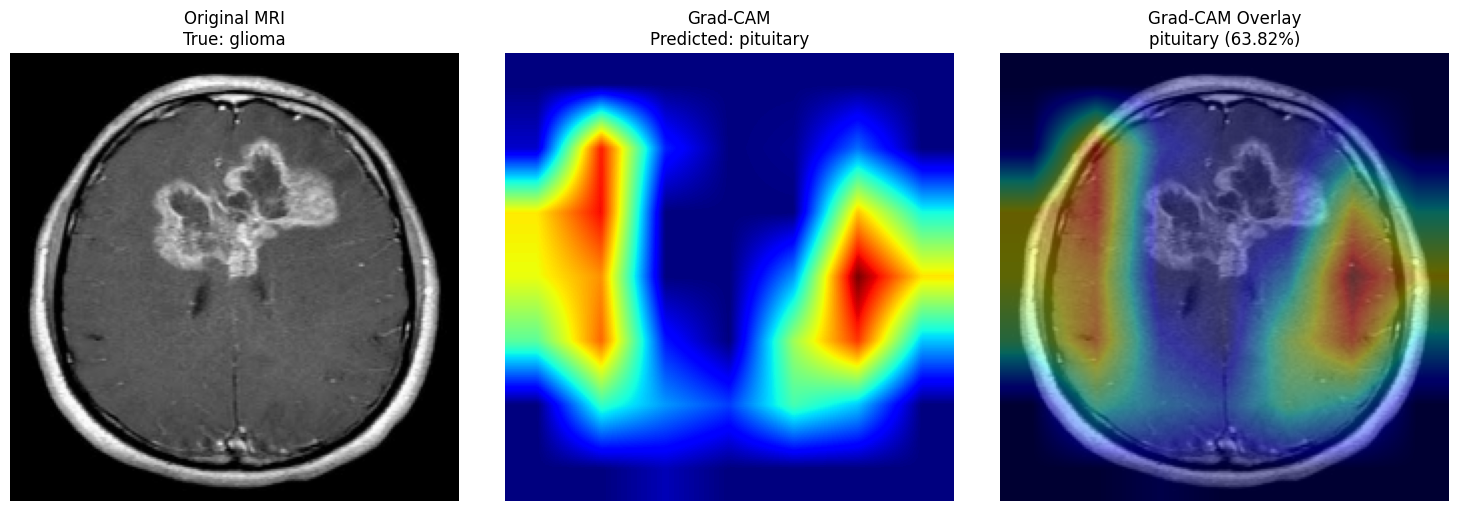

In [87]:
# ==========================================
# GRAD-CAM VISUALIZATION
# ==========================================

plt.figure(figsize=(15, 5))

# ------------------------------------------
# 1. Original MRI
# ------------------------------------------

plt.subplot(1, 3, 1)

plt.imshow(
    sample_image.numpy().astype("uint8")
)

plt.title(
    f"Original MRI\n"
    f"True: {CLASS_NAMES[sample_label.numpy()]}"
)

plt.axis("off")


# ------------------------------------------
# 2. Grad-CAM Heatmap
# ------------------------------------------

plt.subplot(1, 3, 2)

plt.imshow(
    heatmap_resized,
    cmap="jet"
)

plt.title(
    f"Grad-CAM\n"
    f"Predicted: {predicted_class}"
)

plt.axis("off")


# ------------------------------------------
# 3. Overlay
# ------------------------------------------

plt.subplot(1, 3, 3)

plt.imshow(
    sample_image.numpy().astype("uint8")
)

plt.imshow(
    heatmap_resized,
    cmap="jet",
    alpha=0.4
)

plt.title(
    f"Grad-CAM Overlay\n"
    f"{predicted_class} ({confidence:.2%})"
)

plt.axis("off")


plt.tight_layout()
plt.show()

In [88]:
print("Model       :", fine_tuned_model.name)
print("Backbone    :", backbone.name)
print("Grad-CAM    :", LAST_CONV_LAYER)
print("Classes     :", CLASS_NAMES)

Model       : brain_tumor_efficientnetb0
Backbone    : efficientnetb0
Grad-CAM    : top_conv
Classes     : ['glioma', 'meningioma', 'notumor', 'pituitary']


## 15. Function Grad CAM

In [89]:
def generate_gradcam(
    image,
    model,
    backbone,
    last_conv_layer_name,
    pred_index=None
):
    """
    Generate Grad-CAM heatmap untuk satu image.
    """

    # Pastikan image memiliki batch dimension
    if len(image.shape) == 3:
        image_input = tf.expand_dims(image, axis=0)
    else:
        image_input = image

    # Ambil convolution layer
    last_conv_layer = backbone.get_layer(
        last_conv_layer_name
    )

    # Model untuk mendapatkan:
    # 1. feature map dari convolution layer
    # 2. output backbone
    grad_model = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=[
            last_conv_layer.output,
            backbone.output
        ]
    )

    # Gradient calculation
    with tf.GradientTape() as tape:

        conv_outputs, backbone_output = grad_model(
            image_input,
            training=False
        )

        # Global Average Pooling
        pooled_output = tf.reduce_mean(
            backbone_output,
            axis=[1, 2]
        )

        # Classifier
        predictions = model.get_layer(
            "classifier"
        )(pooled_output)

        if pred_index is None:
            pred_index = tf.argmax(
                predictions[0]
            )

        class_channel = predictions[:, pred_index]

    # Gradient
    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    # Global average pooling gradient
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    # Ambil feature map
    conv_outputs = conv_outputs[0]

    pooled_grads = pooled_grads[0]

    # Weighted feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    max_value = tf.reduce_max(
        heatmap
    )

    heatmap = heatmap / (
        max_value + tf.keras.backend.epsilon()
    )

    return heatmap.numpy()

Test function

In [90]:
heatmap_test = generate_gradcam(
    sample_input,
    fine_tuned_model,
    backbone,
    LAST_CONV_LAYER,
    pred_index=predicted_index
)

print("Heatmap shape :", heatmap_test.shape)
print("Heatmap min   :", heatmap_test.min())
print("Heatmap max   :", heatmap_test.max())

Heatmap shape : (7, 7)
Heatmap min   : 0.0
Heatmap max   : 0.9999988


In [91]:
# Sample testing image

def collect_gradcam_samples(
    dataset,
    model,
    target_true,
    target_pred,
    max_samples=4
):

    samples = []

    current_index = 0

    for images, labels in dataset:

        predictions = model.predict(
            images,
            verbose=0
        )

        batch_pred = np.argmax(
            predictions,
            axis=1
        )

        for i in range(len(labels)):

            true_label = int(
                labels[i].numpy()
            )

            predicted_label = int(
                batch_pred[i]
            )

            if (
                true_label == target_true
                and predicted_label == target_pred
            ):

                confidence = float(
                    predictions[i][predicted_label]
                )

                samples.append({
                    "index": current_index + i,
                    "image": images[i],
                    "true_label": true_label,
                    "predicted_label": predicted_label,
                    "confidence": confidence
                })

                if len(samples) >= max_samples:
                    return samples

        current_index += len(labels)

    return samples

In [92]:
meningioma_to_pituitary = collect_gradcam_samples(
    testing_dataset,
    fine_tuned_model,
    target_true=1,
    target_pred=3,
    max_samples=4
)

In [93]:
print(
    "Number of samples:",
    len(meningioma_to_pituitary)
)

for sample in meningioma_to_pituitary:

    print(
        "Index:",
        sample["index"],
        "| True:",
        CLASS_NAMES[sample["true_label"]],
        "| Pred:",
        CLASS_NAMES[sample["predicted_label"]],
        "| Confidence:",
        f"{sample['confidence']:.2%}"
    )

Number of samples: 4
Index: 401 | True: meningioma | Pred: pituitary | Confidence: 91.61%
Index: 409 | True: meningioma | Pred: pituitary | Confidence: 53.26%
Index: 412 | True: meningioma | Pred: pituitary | Confidence: 78.78%
Index: 420 | True: meningioma | Pred: pituitary | Confidence: 94.18%


Visualisasi Sample

In [94]:
def plot_gradcam_samples(
    samples,
    model,
    backbone,
    last_conv_layer_name,
    class_names
):

    n = len(samples)

    plt.figure(
        figsize=(15, 4 * n)
    )

    for i, sample in enumerate(samples):

        image = sample["image"]

        true_label = sample["true_label"]
        predicted_label = sample["predicted_label"]
        confidence = sample["confidence"]

        # Generate heatmap
        image_input = tf.expand_dims(
            image,
            axis=0
        )

        heatmap = generate_gradcam(
            image_input,
            model,
            backbone,
            last_conv_layer_name,
            pred_index=predicted_label
        )

        # Resize
        heatmap_resized = cv2.resize(
            heatmap,
            (224, 224)
        )

        image_np = image.numpy()

        # --------------------------------
        # Original
        # --------------------------------

        plt.subplot(
            n,
            3,
            i * 3 + 1
        )

        plt.imshow(
            image_np.astype("uint8")
        )

        plt.title(
            f"Original\n"
            f"True: {class_names[true_label]}"
        )

        plt.axis("off")

        # --------------------------------
        # Heatmap
        # --------------------------------

        plt.subplot(
            n,
            3,
            i * 3 + 2
        )

        plt.imshow(
            heatmap_resized,
            cmap="jet"
        )

        plt.title(
            f"Grad-CAM\n"
            f"Pred: {class_names[predicted_label]}"
        )

        plt.axis("off")

        # --------------------------------
        # Overlay
        # --------------------------------

        plt.subplot(
            n,
            3,
            i * 3 + 3
        )

        plt.imshow(
            image_np.astype("uint8")
        )

        plt.imshow(
            heatmap_resized,
            cmap="jet",
            alpha=0.4
        )

        plt.title(
            f"Overlay\n"
            f"{class_names[predicted_label]} "
            f"({confidence:.2%})"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

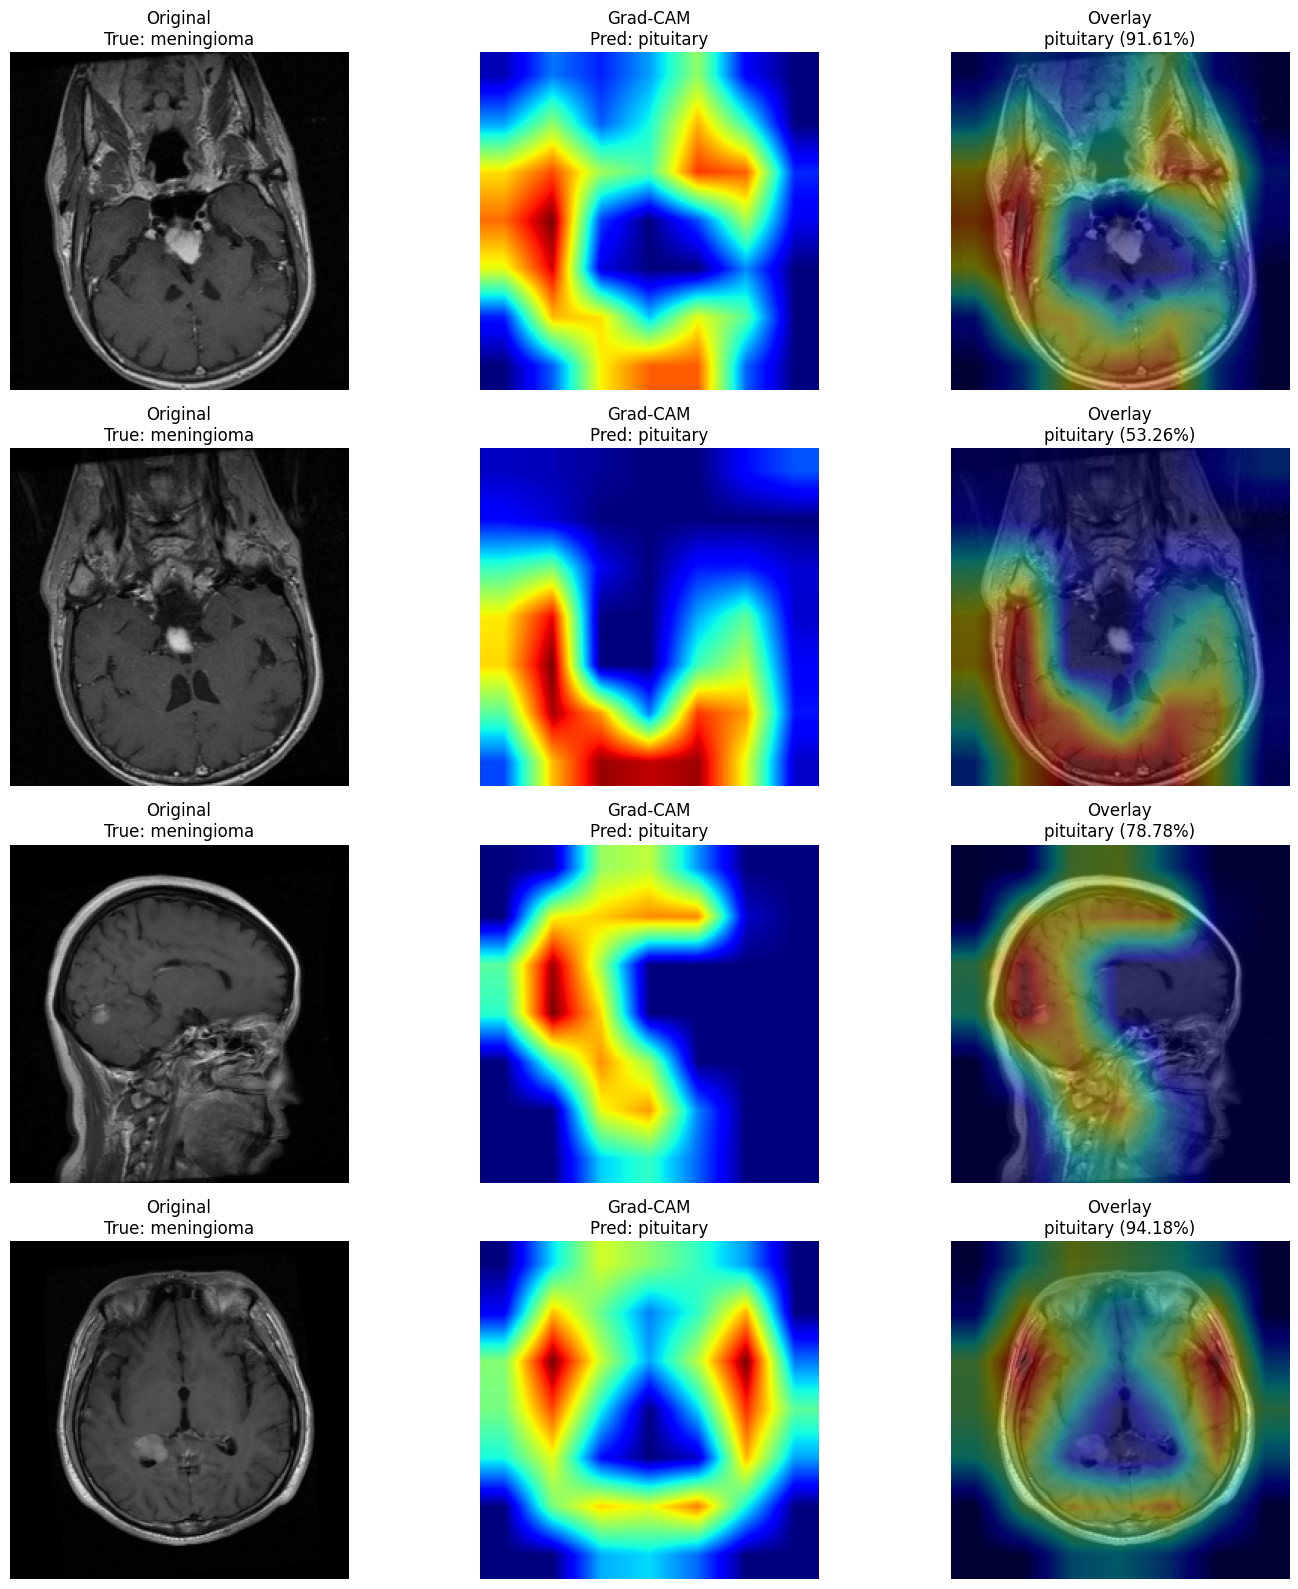

In [95]:
plot_gradcam_samples(
    meningioma_to_pituitary,
    fine_tuned_model,
    backbone,
    LAST_CONV_LAYER,
    CLASS_NAMES
)

Grad-CAM analysis was performed to investigate the visual regions contributing to the model's predictions. The analysis focused on misclassified samples, particularly cases where meningioma was incorrectly classified as pituitary. The results showed that the model frequently produced attention patterns distributed across broad anatomical regions rather than being consistently concentrated on the tumor region. Several misclassified samples also exhibited high prediction confidence, with confidence values exceeding 90%. These findings suggest that although the fine-tuned EfficientNetB0 achieved high overall classification performance, the model may still rely on non-specific anatomical or image-level features in some cases. Therefore, Grad-CAM provides an important qualitative assessment of model behavior beyond conventional accuracy-based evaluation.

## 16. Grad-CAM Final Analysisi

In [96]:
# ==========================================
# SELECT SAMPLES FOR FINAL GRAD-CAM ANALYSIS
# ==========================================

correct_indices = np.where(y_true == y_pred)[0]
incorrect_indices = np.where(y_true != y_pred)[0]

print("Total correct samples   :", len(correct_indices))
print("Total incorrect samples :", len(incorrect_indices))

# Ambil 4 sample pertama dari masing-masing kategori
correct_samples = correct_indices[:4]
incorrect_samples = incorrect_indices[:4]

print("\nCorrect sample indices:")
print(correct_samples)

print("\nIncorrect sample indices:")
print(incorrect_samples)

Total correct samples   : 1052
Total incorrect samples : 68

Correct sample indices:
[2 3 4 5]

Incorrect sample indices:
[ 0  1 52 86]


In [97]:
# ==========================================
# CONVERT TESTING DATASET TO NUMPY ARRAYS
# ==========================================

testing_images = []
testing_labels = []

for images, labels in testing_dataset:
    testing_images.extend(images.numpy())
    testing_labels.extend(labels.numpy())

testing_images = np.array(testing_images)
testing_labels = np.array(testing_labels)

print("Testing images shape :", testing_images.shape)
print("Testing labels shape :", testing_labels.shape)

Testing images shape : (1600, 224, 224, 3)
Testing labels shape : (1600,)


In [98]:
# ==========================================
# GRAD-CAM VISUALIZATION FUNCTION
# ==========================================

def visualize_gradcam_sample(index):
    
    image = testing_images[index]
    
    true_index = y_true[index]
    predicted_index = y_pred[index]
    confidence = y_prob[index][predicted_index]
    
    true_class = CLASS_NAMES[true_index]
    predicted_class = CLASS_NAMES[predicted_index]
    
    # Model input
    sample_input = np.expand_dims(image, axis=0)
    
    # Generate Grad-CAM
    heatmap = make_gradcam_heatmap(
        sample_input,
        fine_tuned_model,
        backbone,
        LAST_CONV_LAYER,
        pred_index=predicted_index
    )
    
    # Resize heatmap
    heatmap_resized = cv2.resize(
        heatmap,
        (224, 224)
    )
    
    # Plot
    plt.figure(figsize=(15, 4))
    
    # Original
    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title(
        f"Original MRI\n"
        f"True: {true_class}"
    )
    plt.axis("off")
    
    # Grad-CAM
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title(
        f"Grad-CAM\n"
        f"Pred: {predicted_class}"
    )
    plt.axis("off")
    
    # Overlay
    plt.subplot(1, 3, 3)
    plt.imshow(image)
    plt.imshow(
        heatmap_resized,
        cmap="jet",
        alpha=0.4
    )
    plt.title(
        f"Overlay\n"
        f"{predicted_class} ({confidence:.2%})"
    )
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()
    
    print(f"Index      : {index}")
    print(f"True       : {true_class}")
    print(f"Predicted  : {predicted_class}")
    print(f"Confidence : {confidence:.2%}")

CORRECT PREDICTIONS


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..242.6582].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..242.6582].


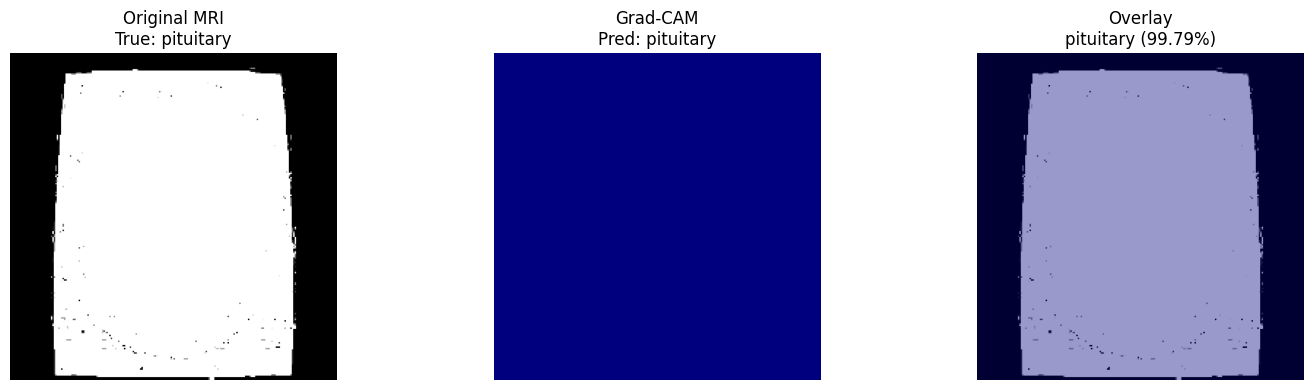

Index      : 2
True       : pituitary
Predicted  : pituitary
Confidence : 99.79%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..252.07655].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..252.07655].


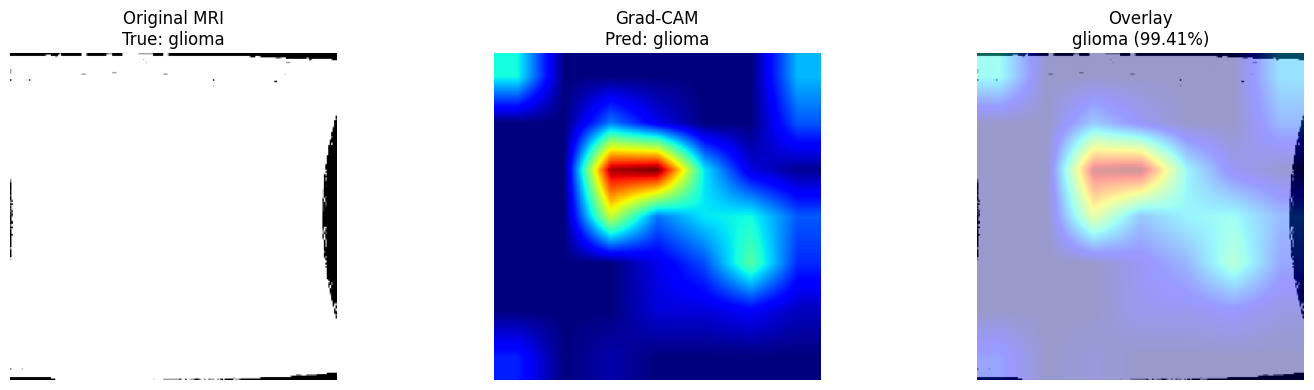

Index      : 3
True       : glioma
Predicted  : glioma
Confidence : 99.41%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..218.33545].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..218.33545].


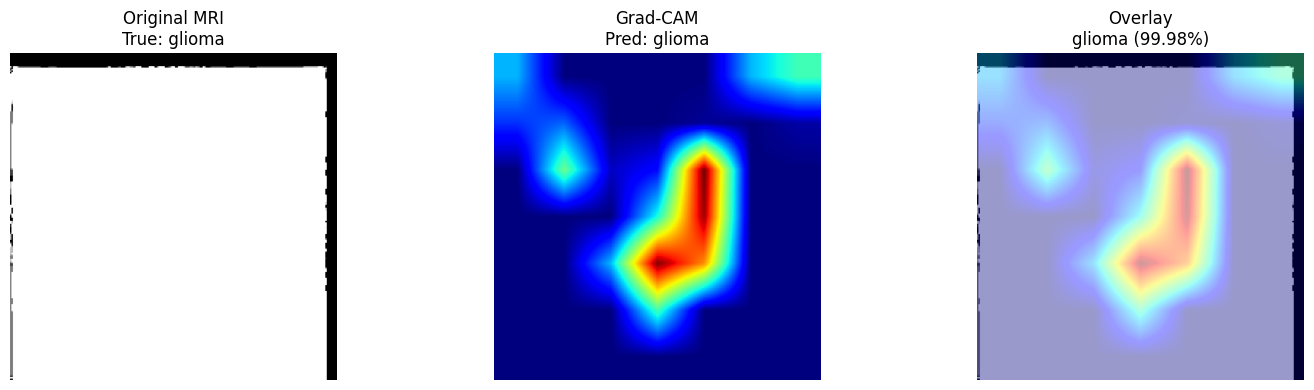

Index      : 4
True       : glioma
Predicted  : glioma
Confidence : 99.98%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.0..254.90617].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.0..254.90617].


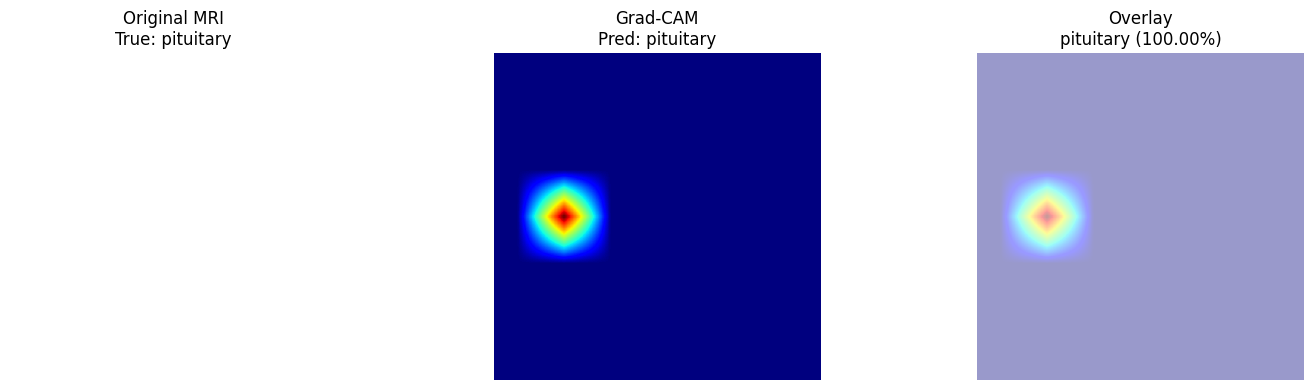

Index      : 5
True       : pituitary
Predicted  : pituitary
Confidence : 100.00%


In [99]:
# ==========================================
# CORRECT PREDICTIONS
# ==========================================

print("==========================================")
print("CORRECT PREDICTIONS")
print("==========================================")

for index in correct_samples:
    visualize_gradcam_sample(index)

INCORRECT PREDICTIONS


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..254.9504].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..254.9504].


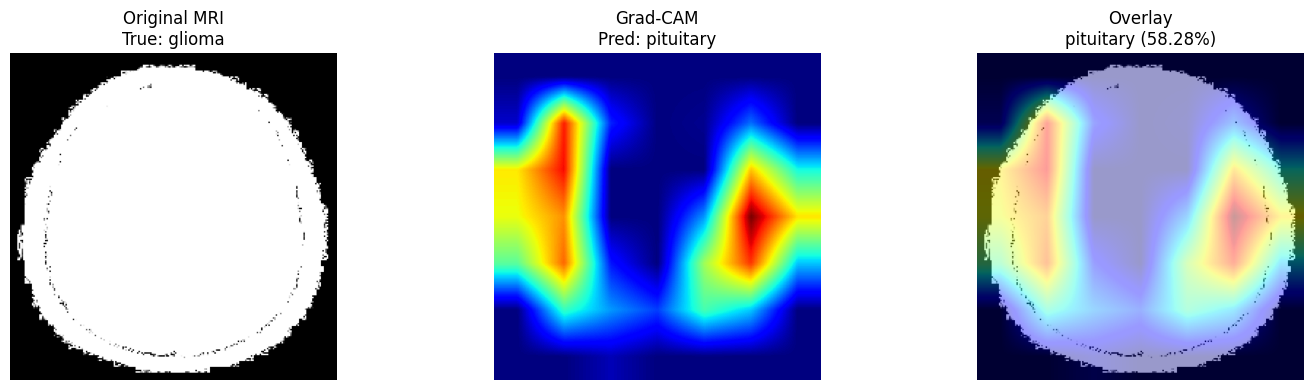

Index      : 0
True       : glioma
Predicted  : pituitary
Confidence : 58.28%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..233.0213].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..233.0213].


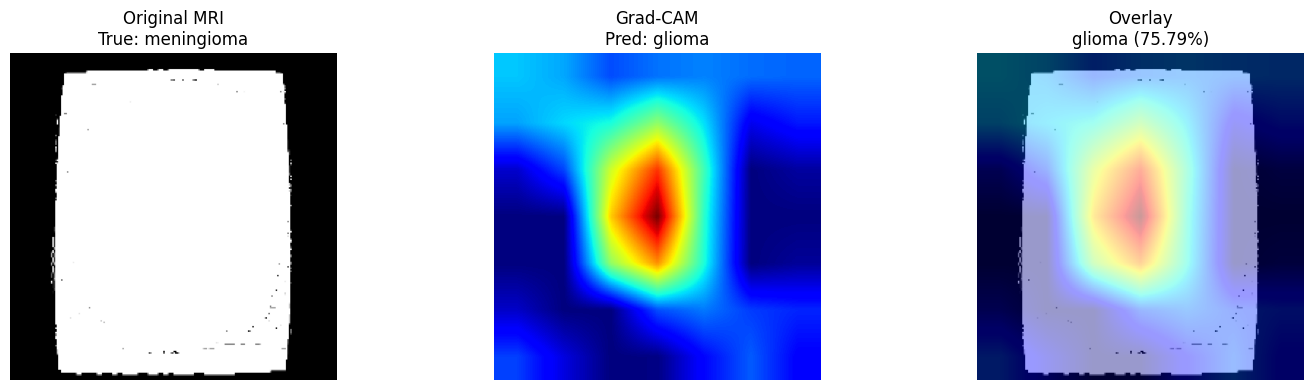

Index      : 1
True       : meningioma
Predicted  : glioma
Confidence : 75.79%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..225.8367].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..225.8367].


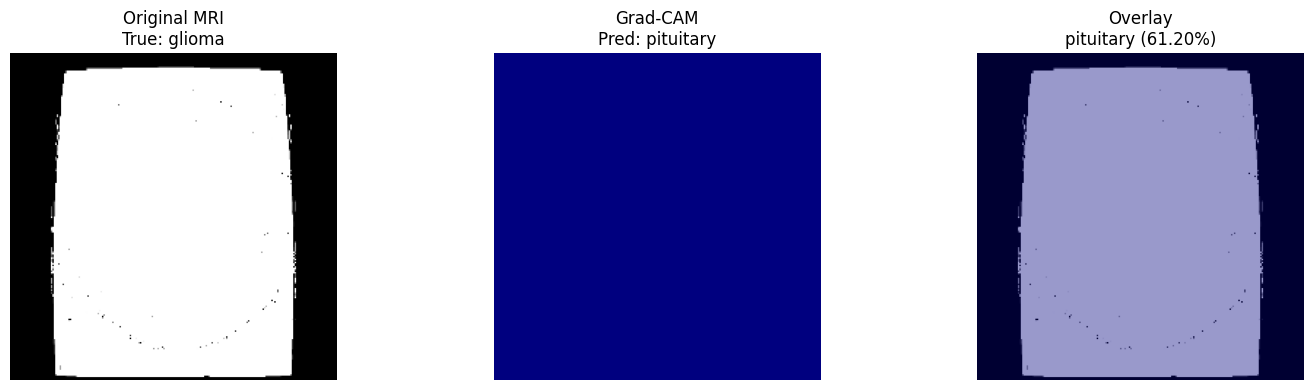

Index      : 52
True       : glioma
Predicted  : pituitary
Confidence : 61.20%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..234.00023].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..234.00023].


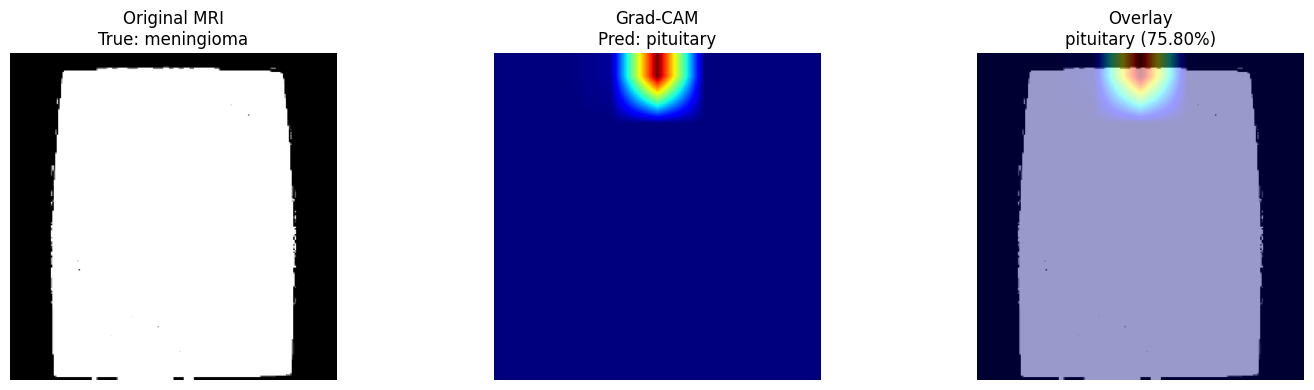

Index      : 86
True       : meningioma
Predicted  : pituitary
Confidence : 75.80%


In [100]:
# ==========================================
# INCORRECT PREDICTIONS
# ==========================================

print("==========================================")
print("INCORRECT PREDICTIONS")
print("==========================================")

for index in incorrect_samples:
    visualize_gradcam_sample(index)

### Variable Testing

In [101]:
# ==========================================
# TESTING PREDICTIONS FOR GRAD-CAM
# ==========================================

testing_y_true = []
testing_y_pred = []
testing_y_prob = []

for images, labels in testing_dataset:

    predictions = fine_tuned_model.predict(
        images,
        verbose=0
    )

    testing_y_true.extend(labels.numpy())
    testing_y_pred.extend(
        np.argmax(predictions, axis=1)
    )
    testing_y_prob.extend(predictions)


testing_y_true = np.array(testing_y_true)
testing_y_pred = np.array(testing_y_pred)
testing_y_prob = np.array(testing_y_prob)

print("Testing true labels shape       :", testing_y_true.shape)
print("Testing predicted labels shape  :", testing_y_pred.shape)
print("Testing probabilities shape     :", testing_y_prob.shape)

print("\nCorrect predictions :",
      np.sum(testing_y_true == testing_y_pred))

print("Incorrect predictions :",
      np.sum(testing_y_true != testing_y_pred))

Testing true labels shape       : (1600,)
Testing predicted labels shape  : (1600,)
Testing probabilities shape     : (1600, 4)

Correct predictions : 1416
Incorrect predictions : 184


In [102]:
print("Images :", testing_images.shape)
print("Labels :", testing_y_true.shape)
print("Pred   :", testing_y_pred.shape)
print("Prob   :", testing_y_prob.shape)

Images : (1600, 224, 224, 3)
Labels : (1600,)
Pred   : (1600,)
Prob   : (1600, 4)


In [103]:
assert len(testing_images) == len(testing_y_true)
assert len(testing_images) == len(testing_y_pred)
assert len(testing_images) == len(testing_y_prob)

print("Testing data and predictions are synchronized.")

Testing data and predictions are synchronized.


In [104]:
# ==========================================
# SELECT TESTING SAMPLES
# ==========================================

testing_correct_indices = np.where(
    testing_y_true == testing_y_pred
)[0]

testing_incorrect_indices = np.where(
    testing_y_true != testing_y_pred
)[0]

print("Total correct samples   :",
      len(testing_correct_indices))

print("Total incorrect samples :",
      len(testing_incorrect_indices))

# Ambil 4 contoh
testing_correct_samples = testing_correct_indices[:4]
testing_incorrect_samples = testing_incorrect_indices[:4]

print("\nCorrect sample indices:")
print(testing_correct_samples)

print("\nIncorrect sample indices:")
print(testing_incorrect_samples)

Total correct samples   : 1416
Total incorrect samples : 184

Correct sample indices:
[1 2 3 6]

Incorrect sample indices:
[0 4 5 8]


In [105]:
def visualize_testing_gradcam(index):

    image = testing_images[index]

    true_index = testing_y_true[index]
    predicted_index = testing_y_pred[index]

    confidence = testing_y_prob[index][predicted_index]

    true_class = CLASS_NAMES[true_index]
    predicted_class = CLASS_NAMES[predicted_index]

    # Model input
    sample_input = np.expand_dims(
        image,
        axis=0
    )

    # Generate Grad-CAM
    heatmap = make_gradcam_heatmap(
        sample_input,
        fine_tuned_model,
        backbone,
        LAST_CONV_LAYER,
        pred_index=predicted_index
    )

    # Resize heatmap
    heatmap_resized = cv2.resize(
        heatmap,
        (224, 224)
    )

    # Plot
    plt.figure(figsize=(15, 4))

    # -------------------------
    # Original MRI
    # -------------------------
    plt.subplot(1, 3, 1)

    plt.imshow(
        image,
        vmin=0,
        vmax=255
    )

    plt.title(
        f"Original MRI\n"
        f"True: {true_class}"
    )

    plt.axis("off")

    # -------------------------
    # Grad-CAM
    # -------------------------
    plt.subplot(1, 3, 2)

    plt.imshow(
        heatmap_resized,
        cmap="jet"
    )

    plt.title(
        f"Grad-CAM\n"
        f"Pred: {predicted_class}"
    )

    plt.axis("off")

    # -------------------------
    # Overlay
    # -------------------------
    plt.subplot(1, 3, 3)

    plt.imshow(
        image,
        vmin=0,
        vmax=255
    )

    plt.imshow(
        heatmap_resized,
        cmap="jet",
        alpha=0.4
    )

    plt.title(
        f"Overlay\n"
        f"{predicted_class} ({confidence:.2%})"
    )

    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Index      : {index}")
    print(f"True       : {true_class}")
    print(f"Predicted  : {predicted_class}")
    print(f"Confidence : {confidence:.2%}")

TESTING - CORRECT PREDICTIONS


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..233.0213].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..233.0213].


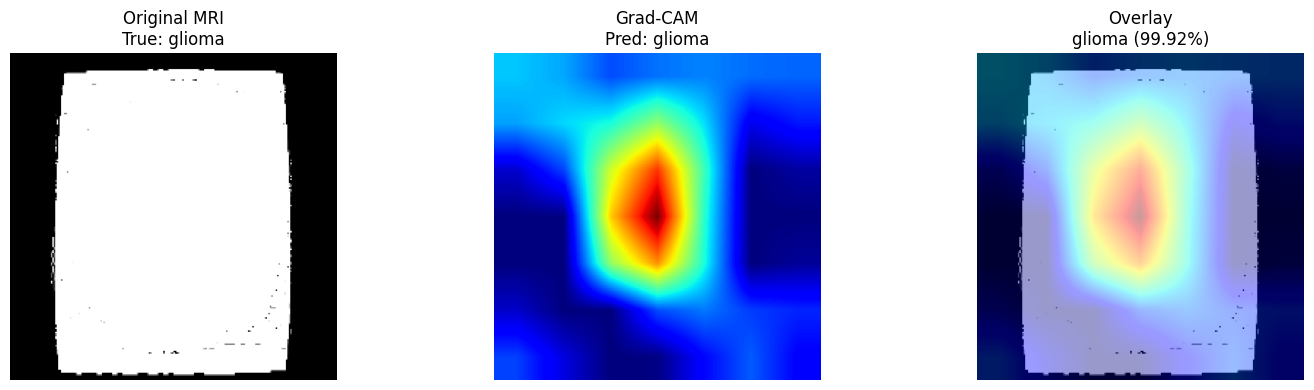

Index      : 1
True       : glioma
Predicted  : glioma
Confidence : 99.92%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..242.6582].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..242.6582].


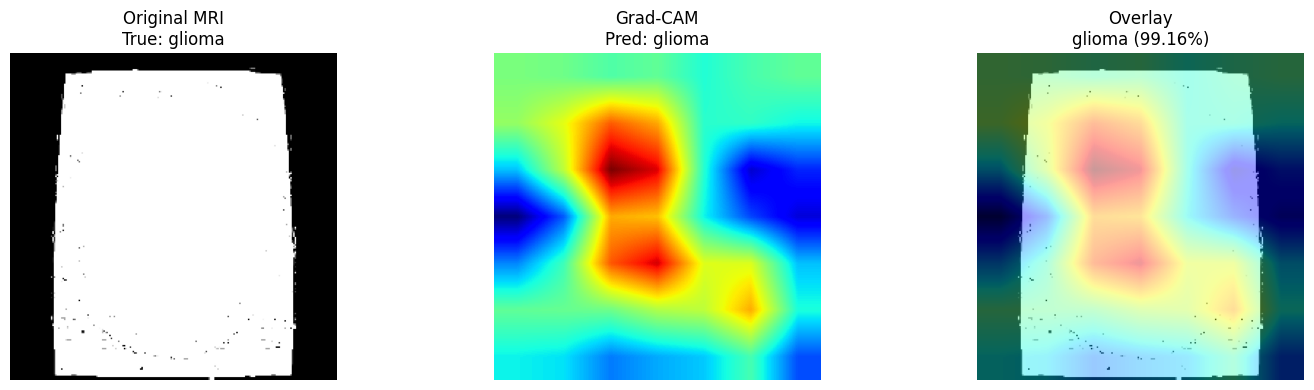

Index      : 2
True       : glioma
Predicted  : glioma
Confidence : 99.16%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..252.07655].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..252.07655].


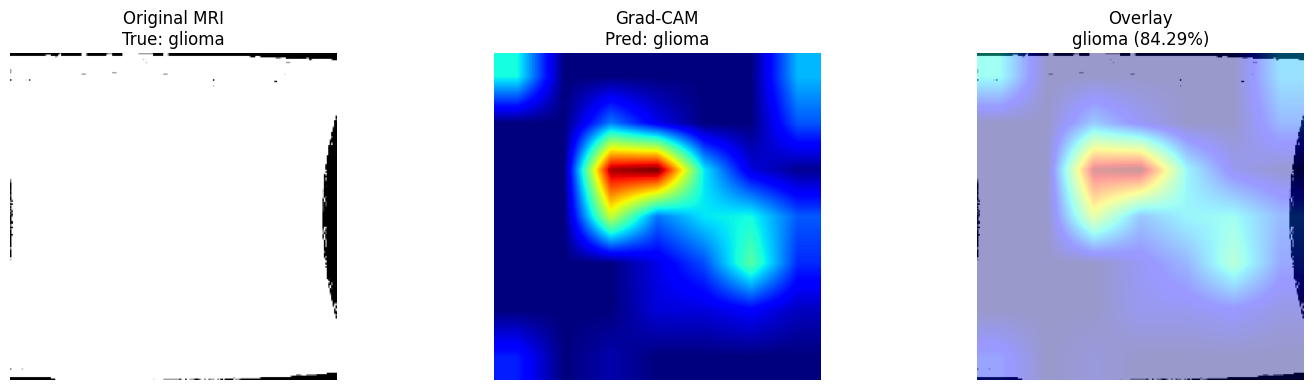

Index      : 3
True       : glioma
Predicted  : glioma
Confidence : 84.29%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..248.15303].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..248.15303].


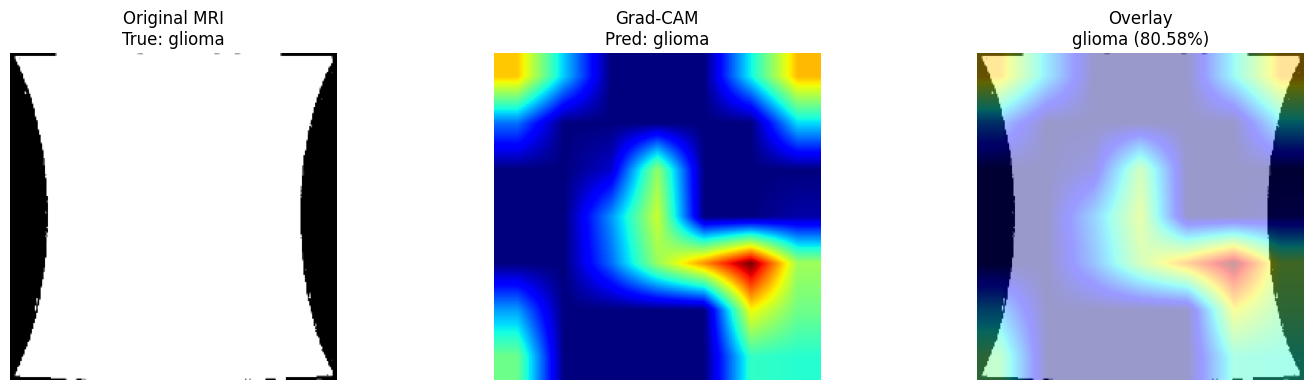

Index      : 6
True       : glioma
Predicted  : glioma
Confidence : 80.58%


In [106]:
print("==========================================")
print("TESTING - CORRECT PREDICTIONS")
print("==========================================")

for index in testing_correct_samples:
    visualize_testing_gradcam(index)

TESTING - INCORRECT PREDICTIONS


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..254.9504].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..254.9504].


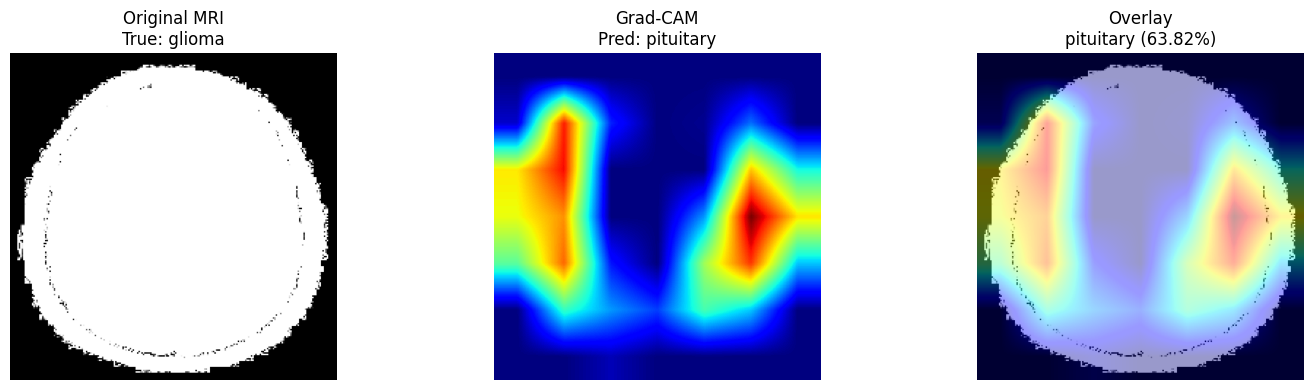

Index      : 0
True       : glioma
Predicted  : pituitary
Confidence : 63.82%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..218.33545].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..218.33545].


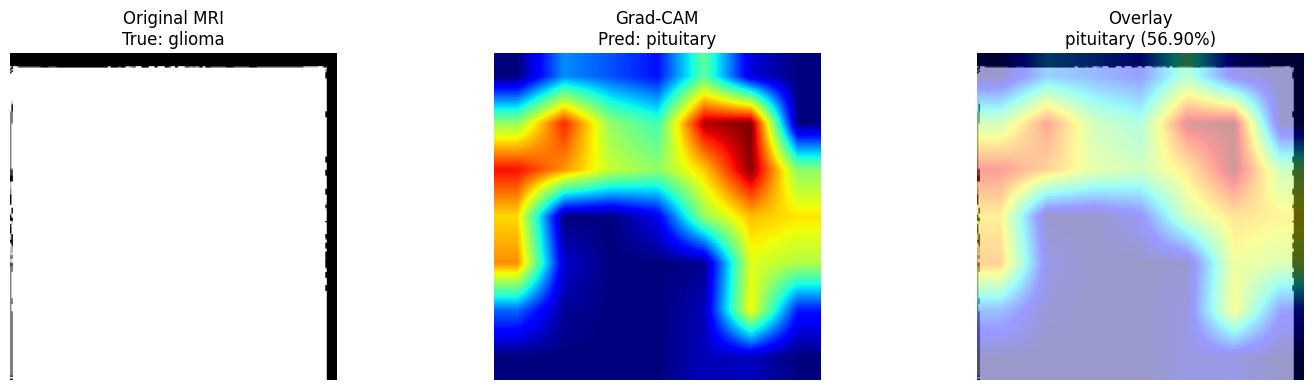

Index      : 4
True       : glioma
Predicted  : pituitary
Confidence : 56.90%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.0..254.90617].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.0..254.90617].


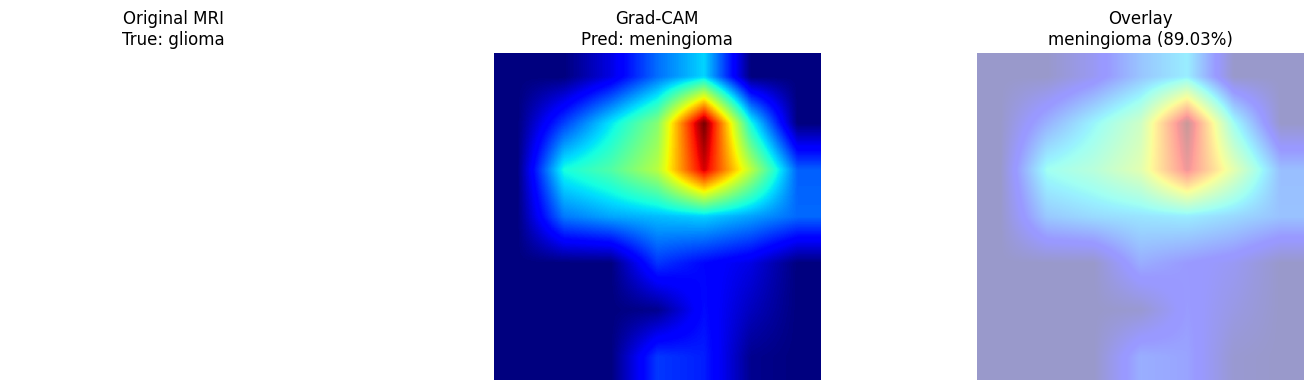

Index      : 5
True       : glioma
Predicted  : meningioma
Confidence : 89.03%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..204.56754].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..204.56754].


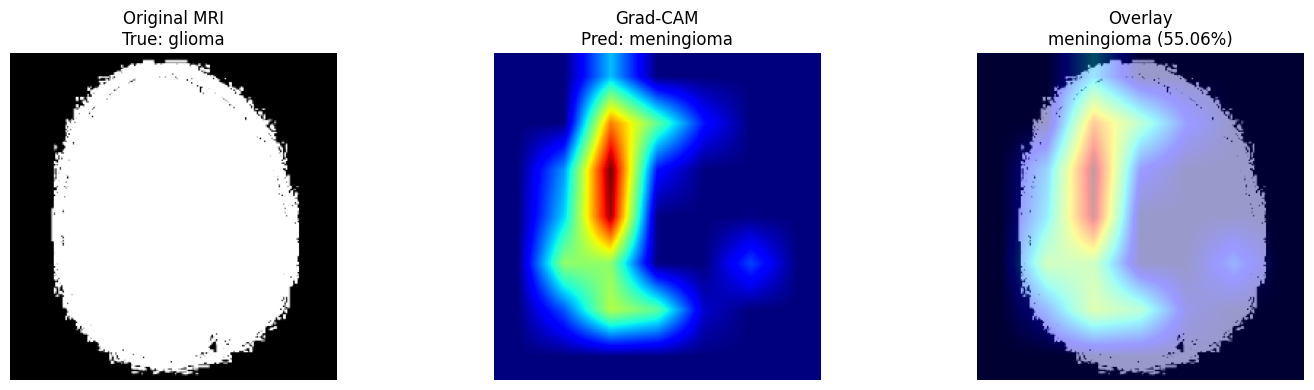

Index      : 8
True       : glioma
Predicted  : meningioma
Confidence : 55.06%


In [107]:
print("==========================================")
print("TESTING - INCORRECT PREDICTIONS")
print("==========================================")

for index in testing_incorrect_samples:
    visualize_testing_gradcam(index)

## 17. Analysis

In [108]:
# ==========================================
# MENINGIOMA → PITUITARY SAMPLES
# ==========================================

meningioma_pituitary_indices = np.where(
    (testing_y_true == CLASS_NAMES.index("meningioma")) &
    (testing_y_pred == CLASS_NAMES.index("pituitary"))
)[0]

print("Total Meningioma → Pituitary:",
      len(meningioma_pituitary_indices))

print("Sample indices:",
      meningioma_pituitary_indices[:4])

Total Meningioma → Pituitary: 60
Sample indices: [401 409 412 420]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..244.89273].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..244.89273].


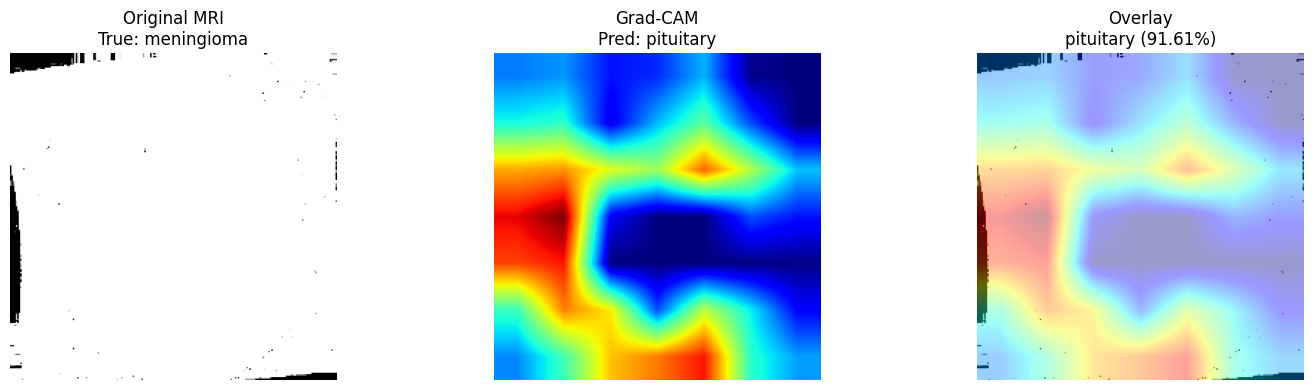

Index      : 401
True       : meningioma
Predicted  : pituitary
Confidence : 91.61%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..248.25476].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..248.25476].


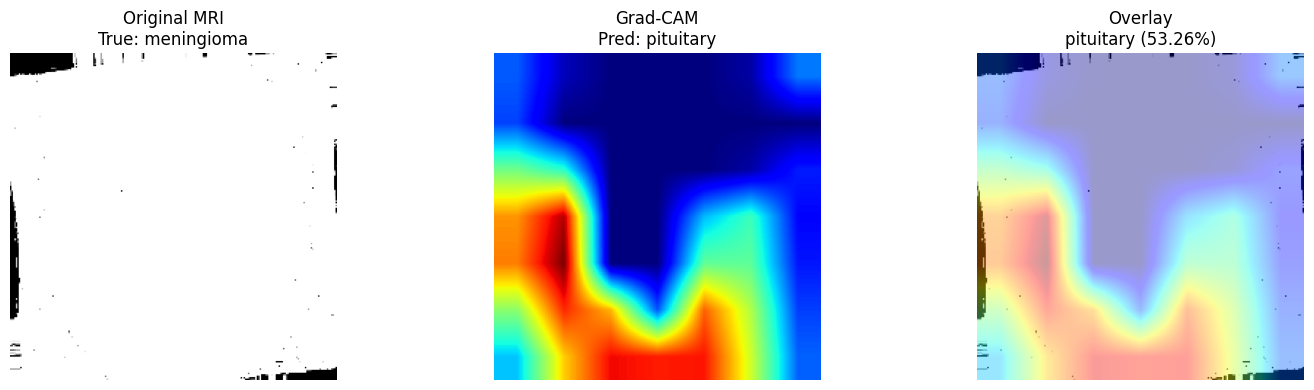

Index      : 409
True       : meningioma
Predicted  : pituitary
Confidence : 53.26%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..247.33675].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..247.33675].


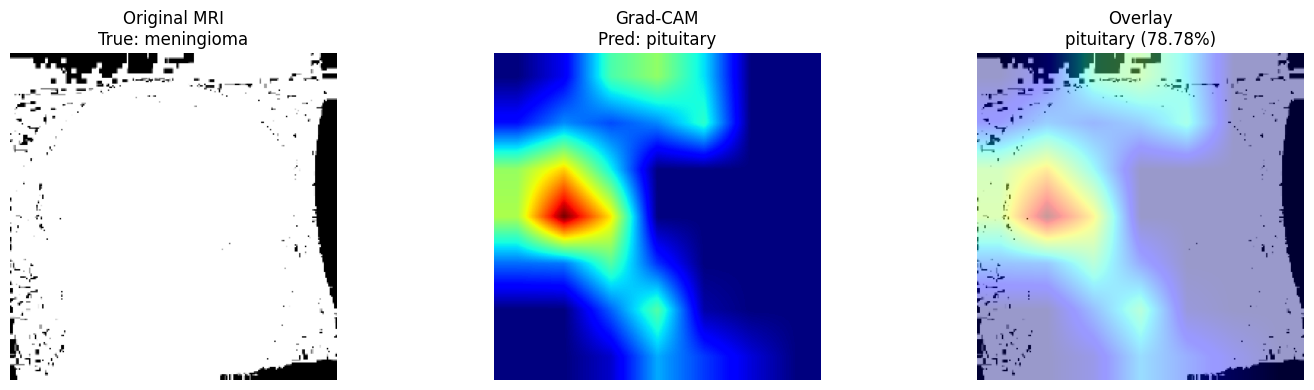

Index      : 412
True       : meningioma
Predicted  : pituitary
Confidence : 78.78%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..247.02097].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..247.02097].


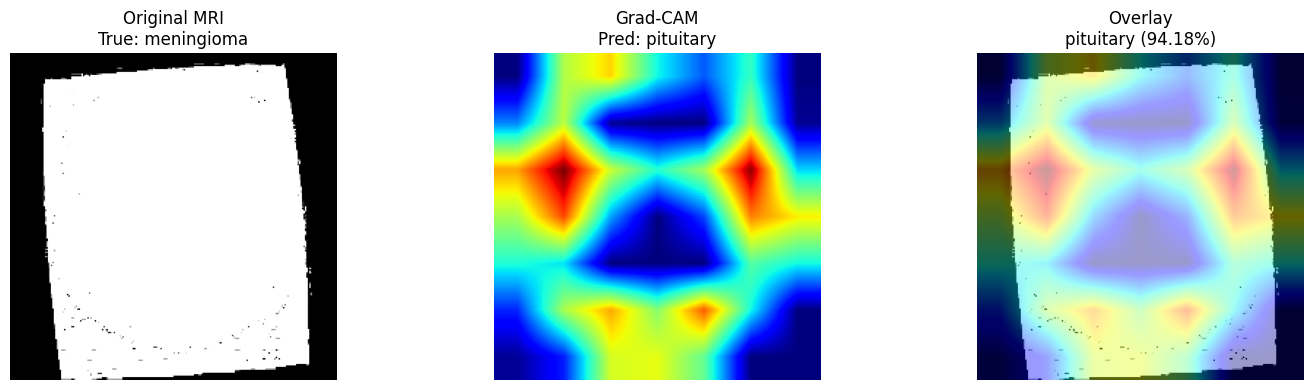

Index      : 420
True       : meningioma
Predicted  : pituitary
Confidence : 94.18%


In [109]:
# ==========================================
# VISUALIZE MENINGIOMA → PITUITARY
# ==========================================

selected_indices = meningioma_pituitary_indices[:4]

for index in selected_indices:
    visualize_testing_gradcam(index)

In [110]:
# ==========================================
# CONFIDENCE MENINGIOMA → PITUITARY
# ==========================================

mp_confidence = testing_y_prob[
    meningioma_pituitary_indices,
    CLASS_NAMES.index("pituitary")
]

print("Meningioma → Pituitary")
print("Number of samples :", len(mp_confidence))
print("Mean confidence   :", mp_confidence.mean())
print("Median confidence :", np.median(mp_confidence))
print("Minimum confidence:", mp_confidence.min())
print("Maximum confidence:", mp_confidence.max())

Meningioma → Pituitary
Number of samples : 60
Mean confidence   : 0.7303845
Median confidence : 0.70203596
Minimum confidence: 0.38768354
Maximum confidence: 0.9989168


Analisis Grad-CAM menunjukkan bahwa kesalahan klasifikasi paling dominan pada kelas meningioma adalah ketika citra diprediksi sebagai pituitary. Terdapat 60 sampel dengan pola kesalahan tersebut pada data testing. Tingkat confidence rata-rata sebesar 73.04% menunjukkan bahwa model cukup yakin terhadap sebagian besar prediksi yang salah, bahkan terdapat prediksi dengan confidence hingga 99.89%. Hal ini mengindikasikan adanya kemungkinan pola visual yang serupa atau fitur yang sulit dibedakan oleh model antara kedua kelas tersebut.

## 18. Final Model Evaluation & Results

In [111]:
# ============================================
# FINAL MODEL EVALUATION
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import pandas as pd
import numpy as np

# Final predictions
accuracy = accuracy_score(y_true_test, y_pred_test)
precision = precision_score(
    y_true_test,
    y_pred_test,
    average="macro"
)
recall = recall_score(
    y_true_test,
    y_pred_test,
    average="macro"
)
f1 = f1_score(
    y_true_test,
    y_pred_test,
    average="macro"
)

error_rate = 1 - accuracy

# Display results
print("============================================")
print("FINAL MODEL EVALUATION")
print("============================================")
print(f"Accuracy          : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Macro Precision   : {precision:.4f} ({precision*100:.2f}%)")
print(f"Macro Recall      : {recall:.4f} ({recall*100:.2f}%)")
print(f"Macro F1-Score    : {f1:.4f} ({f1*100:.2f}%)")
print(f"Error Rate        : {error_rate:.4f} ({error_rate*100:.2f}%)")

FINAL MODEL EVALUATION
Accuracy          : 0.8850 (88.50%)
Macro Precision   : 0.8916 (89.16%)
Macro Recall      : 0.8850 (88.50%)
Macro F1-Score    : 0.8820 (88.20%)
Error Rate        : 0.1150 (11.50%)


In [112]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

report = classification_report(
    y_true_test,
    y_pred_test,
    target_names=CLASS_NAMES,
    digits=4
)

print("============================================")
print("CLASSIFICATION REPORT")
print("============================================")
print(report)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma     0.9522    0.7475    0.8375       400
  meningioma     0.8785    0.7950    0.8346       400
     notumor     0.9194    0.9975    0.9568       400
   pituitary     0.8163    1.0000    0.8989       400

    accuracy                         0.8850      1600
   macro avg     0.8916    0.8850    0.8820      1600
weighted avg     0.8916    0.8850    0.8820      1600



In [113]:
# ============================================
# FINAL RESULTS TABLE
# ============================================

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-Score",
        "Error Rate"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        error_rate
    ],
    "Percentage": [
        f"{accuracy*100:.2f}%",
        f"{precision*100:.2f}%",
        f"{recall*100:.2f}%",
        f"{f1*100:.2f}%",
        f"{error_rate*100:.2f}%"
    ]
})

final_results

,Metric,Score,Percentage
0,Accuracy,0.885000,88.50%
1,Macro Precision,0.891591,89.16%
2,Macro Recall,0.885000,88.50%
3,Macro F1-Score,0.881973,88.20%
4,Error Rate,0.115000,11.50%


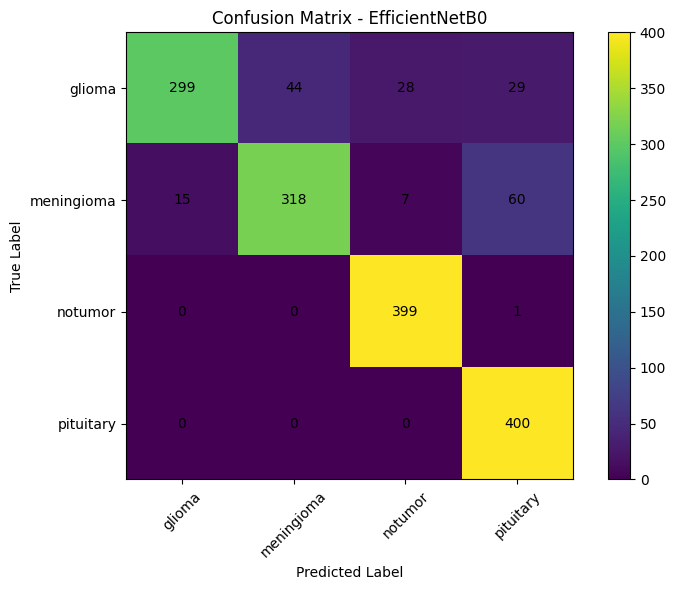

In [114]:
# ============================================
# FINAL CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("Confusion Matrix - EfficientNetB0")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    ticks=np.arange(len(CLASS_NAMES)),
    labels=CLASS_NAMES,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(CLASS_NAMES)),
    labels=CLASS_NAMES
)

# Menampilkan angka pada setiap sel
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

## 19. Baseline Vs Fine Tuned

In [115]:
# ============================================
# BASELINE VS FINE-TUNED
# ============================================

comparison = pd.DataFrame({
    "Model": [
        "EfficientNetB0 Baseline",
        "EfficientNetB0 Fine-Tuned"
    ],
    "Validation Accuracy": [
        0.8616,
        0.9393
    ]
})

comparison["Improvement"] = [
    "-",
    f"{(0.9393 - 0.8616) * 100:.2f}%"
]

comparison

,Model,Validation Accuracy,Improvement
0,EfficientNetB0 Baseline,0.8616,-
1,EfficientNetB0 Fine-Tuned,0.9393,7.77%


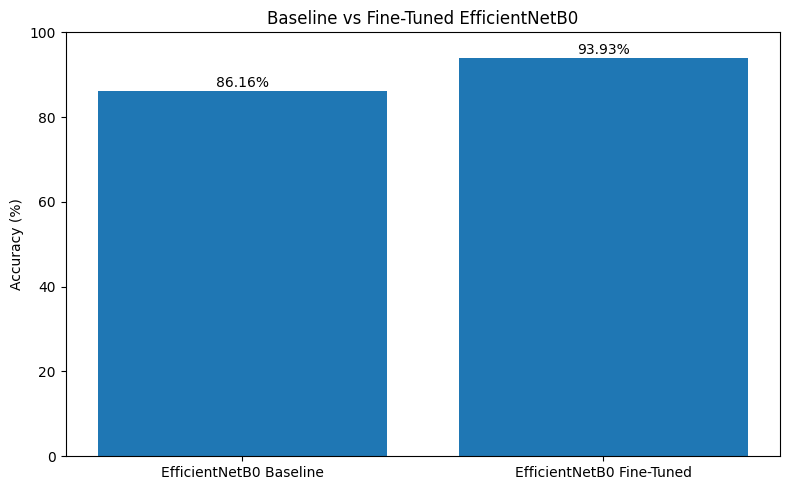

In [116]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Validation Accuracy"] * 100
)

plt.ylabel("Accuracy (%)")
plt.title("Baseline vs Fine-Tuned EfficientNetB0")
plt.ylim(0, 100)

for i, value in enumerate(comparison["Validation Accuracy"] * 100):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 20. Results And Discussion

## 1. Overall Model Performance

The fine-tuned EfficientNetB0 model was evaluated using a testing dataset consisting of 1,600 MRI images from four classes: *glioma*, *meningioma*, *notumor*, and *pituitary*. The dataset contained 400 images for each class.

The model achieved an overall accuracy of **88.50%**, with a macro precision of **89.16%**, macro recall of **88.50%**, and macro F1-score of **88.20%**.

| Metric | Result |
|---|---:|
| Accuracy | **88.50%** |
| Macro Precision | **89.16%** |
| Macro Recall | **88.50%** |
| Macro F1-Score | **88.20%** |
| Error Rate | **11.50%** |

These results indicate that the fine-tuned EfficientNetB0 model was able to classify the MRI images with relatively good performance on unseen testing data. However, the performance varied across the four classes.

---

## 2. Performance by Class

The detailed classification results are shown below.

| Class | Precision | Recall | F1-Score |
|---|---:|---:|---:|
| Glioma | 95.22% | 74.75% | 83.75% |
| Meningioma | 87.85% | 79.50% | 83.46% |
| No Tumor | 91.94% | **99.75%** | **95.68%** |
| Pituitary | 81.63% | **100.00%** | 89.89% |

The **notumor** class achieved the best overall performance, with an F1-score of **95.68%** and a recall of **99.75%**. This indicates that the model was highly effective at distinguishing images without tumors from the other classes.

The **pituitary** class also achieved a recall of **100%**, meaning that all 400 pituitary images in the testing dataset were correctly identified. However, its precision was lower at 81.63%, indicating that some images from other classes were incorrectly predicted as pituitary.

In contrast, **glioma and meningioma were more challenging classes** for the model. Glioma achieved a high precision of 95.22% but a lower recall of 74.75%, while meningioma achieved a precision of 87.85% and recall of 79.50%. These results indicate that the model still had difficulty distinguishing some tumor types from one another.

---

## 3. Confusion Matrix Analysis

The confusion matrix shows that the model correctly classified **1,416 out of 1,600 testing images**, while **184 images were misclassified**, resulting in an error rate of **11.50%**.

The most frequent misclassification patterns were:

- **Meningioma → Pituitary:** 60 cases
- **Glioma → Meningioma:** 44 cases
- **Glioma → Pituitary:** 29 cases
- **Glioma → No Tumor:** 28 cases
- **Meningioma → Glioma:** 15 cases
- **Meningioma → No Tumor:** 7 cases
- **No Tumor → Pituitary:** 1 case

The largest source of classification errors was the **meningioma-to-pituitary** class confusion, followed by **glioma-to-meningioma** confusion. This suggests that the model had more difficulty distinguishing between certain tumor classes, while the *notumor* and *pituitary* classes were generally easier for the model to recognize.

---

## 4. Confidence Analysis

The confidence analysis provides additional information about the model's prediction behavior. Across the testing dataset, the model achieved an average prediction confidence of approximately **93.36%**.

Correct predictions had an average confidence of approximately **95.55%**, while incorrect predictions had a lower average confidence of approximately **76.49%**.

Although confidence was generally lower for incorrect predictions, **58 misclassified images had a confidence of at least 90%**. This indicates that the model could sometimes produce incorrect predictions with high confidence.

Therefore, a high prediction confidence should not automatically be interpreted as a correct prediction. The result also suggests that the model may exhibit some degree of overconfidence on difficult or ambiguous MRI images.

---

## 5. Grad-CAM Analysis

Grad-CAM was used to provide a visual interpretation of the regions that contributed to the model's predictions.

The Grad-CAM analysis included both correctly classified and incorrectly classified testing samples. In several incorrect predictions, particularly cases where **meningioma was classified as pituitary**, the activation areas appeared relatively broad and were not always concentrated on a specific region of the image.

This observation suggests that the model may rely on a combination of visual and contextual features when making its predictions. However, this interpretation should be treated cautiously because Grad-CAM provides a coarse visualization of model attention and does not represent tumor segmentation or clinical localization.

Therefore, the Grad-CAM results are primarily useful for understanding the model's behavior rather than determining whether the model focuses on clinically relevant tumor regions.

---

## 6. Baseline vs. Fine-Tuned Model

Fine-tuning improved the validation performance of the EfficientNetB0 model. The validation accuracy increased from approximately **86.16% for the baseline model to 93.93% after fine-tuning**, representing an improvement of approximately **7.77 percentage points**.

| Model | Validation Accuracy |
|---|---:|
| EfficientNetB0 Baseline | 86.16% |
| EfficientNetB0 Fine-Tuned | **93.93%** |
| Improvement | **+7.77 percentage points** |

This improvement indicates that allowing selected layers of the pretrained backbone to adapt to the MRI dataset helped the model learn more task-specific visual representations.

---

## 7. Discussion

Overall, the fine-tuned EfficientNetB0 model achieved a testing accuracy of **88.50%** and a macro F1-score of **88.20%**. The results demonstrate that transfer learning and fine-tuning can be used to build a relatively effective image classification model for this MRI dataset.

The model performed particularly well on the *notumor* and *pituitary* classes, while *glioma* and *meningioma* remained more difficult to classify. The confusion matrix showed that most classification errors were concentrated between these classes, especially the **meningioma-to-pituitary** and **glioma-to-meningioma** prediction patterns.

The confidence analysis also showed that the model can occasionally be highly confident in incorrect predictions. This highlights the importance of evaluating the model using multiple metrics rather than relying only on accuracy or prediction confidence.

The Grad-CAM analysis provided additional insight into the model's decision-making behavior. However, because the dataset does not contain tumor localization annotations, the visualizations should not be interpreted as clinical evidence of tumor localization.

Overall, the experiment demonstrates the potential of EfficientNetB0 as a feature extractor and classifier for MRI image classification. Nevertheless, the model should be considered an **experimental machine learning model and not a clinical diagnostic tool**. Further improvements could involve using a larger and more diverse dataset, applying more systematic hyperparameter optimization, improving data preprocessing, and evaluating model calibration and generalization on external datasets.

# Conclusion

This project developed a brain tumor MRI image classification model using the EfficientNetB0 architecture and transfer learning. The model was fine-tuned on a dataset containing four classes: *glioma*, *meningioma*, *notumor*, and *pituitary*.
The fine-tuned model achieved an accuracy of **88.50%** and a macro F1-score of **88.20%** on the testing dataset. The model performed particularly well on the *notumor* and *pituitary* classes, while *glioma* and *meningioma* remained more challenging due to a higher number of misclassifications between classes.
The confusion matrix and confidence analysis showed that the majority of classification errors occurred between tumor classes, with **meningioma being most frequently classified as pituitary**. Grad-CAM analysis provided additional insight into the visual features used by the model, although it should not be interpreted as clinical tumor localization.
Overall, this project demonstrates how transfer learning with EfficientNetB0 can be applied to MRI image classification. The resulting model is intended for **educational and experimental purposes only** and should not be used as a clinical diagnostic system.
Future improvements could include using a larger and more diverse dataset, applying more systematic hyperparameter optimization, improving image preprocessing, and evaluating the model on external datasets to better assess its generalization capability.